# Diagnóstico e comparação de runtimes com Prometheus

Este notebook analisa **uma execução por runtime** e somente libera a comparação quando vLLM, llama.cpp e Ollama pertencem ao mesmo experimento controlado.

O fluxo é offline: lê os CSVs consolidados já baixados, não abre túnel, não chama os runtimes e não consulta Prometheus. A unidade estatística é a requisição. Amostras temporais descrevem a requisição, mas não são repetições independentes.

Regras de leitura:

- ausência de métrica permanece ausente; nunca significa uso zero;
- `TTFT/prefill observado` inclui fila, protocolo, tokenização e agendamento;
- utilização alta de CPU/GPU é um sinal diagnóstico, não um ranking de qualidade;
- cada runtime recebe uma conclusão própria antes da comparação;
- não há vencedor comparativo se o gate de identidade experimental falhar.

## 0. Configuração e métodos comuns

Edite somente a célula de configuração para trocar o dataset, as três execuções e as metas do caso de uso. Os métodos abaixo apenas selecionam, resumem e desenham operações repetidas.

In [29]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

configured_dataset = os.environ.get("OBSERVABILITY_DATASET_DIR")
dataset_candidates = [
    Path(configured_dataset).expanduser() if configured_dataset else None,
    Path("../data/runtime-observability"),
    Path("analytics/data/runtime-observability"),
]
DATASET_DIR = next(
    (candidate.resolve() for candidate in dataset_candidates if candidate and (candidate / "dataset-manifest.json").is_file()),
    (Path(configured_dataset).expanduser().resolve() if configured_dataset else Path("../data/runtime-observability").resolve()),
)

RUN_IDS = {
    "vllm": os.environ.get("OBSERVABILITY_RUN_ID_VLLM")
    or "20260928T204903.141552Z-vllm-benchmark-short-medium-long",
    "llama": os.environ.get("OBSERVABILITY_RUN_ID_LLAMA") or None,
    "ollama": os.environ.get("OBSERVABILITY_RUN_ID_OLLAMA") or None,
}

RUNTIME_LABELS = {"vllm": "vLLM", "llama": "llama.cpp", "ollama": "Ollama"}
RUNTIME_COLORS = {"vllm": "#3B6FB6", "llama": "#E07A36", "ollama": "#2E9B65"}
SCENARIO_ORDER = ["short", "medium", "long"]
PHASE = "measure"
TIMELINE_SCENARIO = "long"
MIN_TELEMETRY_COVERAGE = 0.80

# Metas devem ser justificadas pelo caso de uso. None significa "ainda não definida".
SLO = {
    "ttft_p95_ms_max": None,
    "decode_p05_tps_min": None,
    "success_rate_pct_min": 100.0,
}

RESOURCE_CATALOG = {
    "inference_gpu_utilization_ratio": {
        "label": "GPU", "group": "processamento", "kind": "gauge", "scale": 100.0, "unit": "%"
    },
    "inference_gpu_memory_controller_utilization_ratio": {
        "label": "Controlador de memória GPU", "group": "processamento", "kind": "gauge", "scale": 100.0, "unit": "%"
    },
    "inference_host_cpu_utilization_ratio": {
        "label": "CPU do host", "group": "processamento", "kind": "gauge", "scale": 100.0, "unit": "%"
    },
    "inference_gpu_memory_used_bytes": {
        "label": "VRAM usada", "group": "memória", "kind": "gauge", "scale": 1 / 1024**3, "unit": "GiB"
    },
    "inference_host_memory_used_bytes": {
        "label": "RAM usada", "group": "memória", "kind": "gauge", "scale": 1 / 1024**3, "unit": "GiB"
    },
    "inference_host_swap_used_bytes": {
        "label": "Swap usada", "group": "memória", "kind": "gauge", "scale": 1 / 1024**3, "unit": "GiB"
    },
    "inference_gpu_power_watts": {
        "label": "Potência GPU", "group": "operação", "kind": "gauge", "scale": 1.0, "unit": "W"
    },
    "inference_gpu_temperature_celsius": {
        "label": "Temperatura GPU", "group": "operação", "kind": "gauge", "scale": 1.0, "unit": "°C"
    },
    "inference_host_disk_read_bytes_total": {
        "label": "Leitura de disco", "group": "I/O", "kind": "counter", "scale": 1 / 1024**2, "unit": "MiB/req", "rate_unit": "MiB/s"
    },
    "inference_host_disk_write_bytes_total": {
        "label": "Escrita de disco", "group": "I/O", "kind": "counter", "scale": 1 / 1024**2, "unit": "MiB/req", "rate_unit": "MiB/s"
    },
    "inference_host_swap_in_bytes_total": {
        "label": "Swap in", "group": "pressão", "kind": "counter", "scale": 1 / 1024**2, "unit": "MiB/req", "rate_unit": "MiB/s"
    },
    "inference_host_swap_out_bytes_total": {
        "label": "Swap out", "group": "pressão", "kind": "counter", "scale": 1 / 1024**2, "unit": "MiB/req", "rate_unit": "MiB/s"
    },
    "inference_host_page_faults_total": {
        "label": "Page faults", "group": "pressão", "kind": "counter", "scale": 1.0, "unit": "eventos/req", "rate_unit": "eventos/s"
    },
    "inference_host_major_page_faults_total": {
        "label": "Major page faults", "group": "pressão", "kind": "counter", "scale": 1.0, "unit": "eventos/req", "rate_unit": "eventos/s"
    },
    "vllm:kv_cache_usage_perc": {
        "label": "Pool KV", "group": "cache", "kind": "gauge", "scale": 100.0, "unit": "%", "cross_runtime": False
    },
}

display(Markdown(f"**Dataset:** `{DATASET_DIR}`"))
display(
    pd.DataFrame(
        [{"runtime": RUNTIME_LABELS[key], "run_id": value or "não configurado"} for key, value in RUN_IDS.items()]
    )
)

**Dataset:** `/home/THIAGO.OUVERNEY/Projects/finance-agent-platform/analytics/data/runtime-observability`

,runtime,run_id
0,vLLM,20260929T012630.907849Z-vllm-benchmark-short-m...
1,llama.cpp,20260929T013953.801869Z-llama.cpp-benchmark-sh...
2,Ollama,20260929T014325.656279Z-ollama-benchmark-short...


In [30]:
TABLE_FILES = {
    "inventory": "run-inventory.csv",
    "runs": "complete-runs.csv",
    "groups": "comparison-groups.csv",
    "requests": "all-requests.csv",
    "events": "request-events.csv",
    "phase_metrics": "request-phase-metrics.csv",
    "telemetry": "telemetry-by-request.csv",
    "samples": "prometheus-samples.csv",
    "summary": "experiment-summary.csv",
    "coverage": "metric-coverage.csv",
}

def read_table(filename):
    path = DATASET_DIR / filename
    return pd.read_csv(path, low_memory=False) if path.is_file() else pd.DataFrame()

manifest_path = DATASET_DIR / "dataset-manifest.json"
dataset_manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.is_file() else {}
tables = {name: read_table(filename) for name, filename in TABLE_FILES.items()}
DATASET_READY = bool(dataset_manifest)

if DATASET_READY:
    display(
        pd.DataFrame(
            [{
                "runs descobertas": dataset_manifest.get("runs_discovered"),
                "completas": dataset_manifest.get("runs_complete"),
                "excluídas": dataset_manifest.get("runs_excluded"),
                "grupos": dataset_manifest.get("comparison_groups"),
            }]
        )
    )
    inventory_columns = [
        column for column in
        ["run_id", "runtime", "model", "status", "included_in_comparison", "comparison_id"]
        if column in tables["inventory"]
    ]
    if inventory_columns:
        display(tables["inventory"][inventory_columns])
else:
    display(Markdown("**Dataset não encontrado.** Corrija `DATASET_DIR` e execute novamente."))

,runs descobertas,completas,excluídas,grupos
0,9,8,1,4


,run_id,runtime,model,status,included_in_comparison,comparison_id
0,20260929T012220.013082Z-llama.cpp-smoke-short-...,llama.cpp,qwen2.5-7b-test,complete,True,e01a0fa8f55043f5
1,20260929T013953.801869Z-llama.cpp-benchmark-sh...,llama.cpp,qwen2.5-7b-test,complete,True,a5577c32bf8cc6b3
2,20260929T012416.089633Z-ollama-smoke-short-med...,ollama,qwen2.5-7b-test,complete,True,e01a0fa8f55043f5
3,20260929T014325.656279Z-ollama-benchmark-short...,ollama,qwen2.5-7b-test,complete,True,a5577c32bf8cc6b3
4,20260928T203810.382160Z-vllm-smoke-short-mediu...,vllm,qwen2.5-7b-test,failed,False,2e779647020ce41c
5,20260928T204211.453702Z-vllm-smoke-short-mediu...,vllm,qwen2.5-7b-test,complete,True,29c1ed8eb9f2b007
6,20260928T204903.141552Z-vllm-benchmark-short-m...,vllm,qwen2.5-7b-test,complete,True,feee221eeeaa6539
7,20260929T010124.115402Z-vllm-smoke-short-mediu...,vllm,qwen2.5-7b-test,complete,True,e01a0fa8f55043f5
8,20260929T012630.907849Z-vllm-benchmark-short-m...,vllm,qwen2.5-7b-test,complete,True,a5577c32bf8cc6b3


In [31]:
def truthy(value):
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "sim"}
    return bool(value)


def json_value(value, default=None):
    if isinstance(value, (dict, list)):
        return value
    if pd.isna(value) or value in (None, ""):
        return default
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError):
        return default


def filter_run(frame, run_id):
    if frame.empty or not run_id:
        return frame.iloc[0:0].copy()
    for column in ("source_run_id", "run_id", "experiment_id"):
        if column in frame:
            return frame.loc[frame[column].astype(str) == str(run_id)].copy()
    return frame.iloc[0:0].copy()


def numeric_candidate(frame, candidates, factor=1.0):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    for column in candidates:
        if column in frame:
            values = pd.to_numeric(frame[column], errors="coerce") * factor
            result = result.where(result.notna(), values)
    return result


def enrich_scenario(frame, requests):
    result = frame.copy()
    if result.empty:
        return result
    if "scenario" not in result:
        result["scenario"] = np.nan
    if "request_uid" in result and "request_uid" in requests and "scenario" in requests:
        scenario_by_request = requests.dropna(subset=["request_uid"]).drop_duplicates("request_uid").set_index("request_uid")["scenario"]
        mapped = result["request_uid"].map(scenario_by_request)
        result["scenario"] = result["scenario"].where(result["scenario"].notna(), mapped)
    result["scenario"] = result["scenario"].fillna("sem cenário").astype(str)
    return result


def expected_runtime_matches(runtime_key, actual):
    actual = str(actual or "").lower()
    aliases = {
        "vllm": {"vllm"},
        "llama": {"llama", "llama.cpp", "llamacpp"},
        "ollama": {"ollama"},
    }
    return actual in aliases[runtime_key]


def select_run(runtime_key, run_id):
    result = {
        "runtime_key": runtime_key,
        "label": RUNTIME_LABELS[runtime_key],
        "run_id": run_id,
        "configured": bool(run_id),
        "found": False,
        "ready": False,
        "issues": [],
        "identity": pd.Series(dtype=object),
    }
    for table_name in ("inventory", "runs", "requests", "events", "phase_metrics", "telemetry", "samples", "summary", "coverage"):
        result[table_name] = filter_run(tables[table_name], run_id)

    if not run_id:
        result["issues"].append(f"Preencha RUN_IDS[{runtime_key!r}] na configuração.")
        return result

    inventory = result["inventory"]
    complete = result["runs"]
    if complete.empty and inventory.empty:
        result["issues"].append("Run não encontrada no dataset consolidado.")
        return result

    result["found"] = True
    identity = complete.iloc[0] if not complete.empty else inventory.iloc[0]
    result["identity"] = identity
    status = str(identity.get("status", "desconhecido"))
    if status != "complete":
        result["issues"].append(f"Status da run: {status}.")
    if "integrity_ok" in identity and not truthy(identity.get("integrity_ok")):
        result["issues"].append("A integridade dos artefatos não foi aprovada.")
    if "included_in_comparison" in identity and not truthy(identity.get("included_in_comparison")):
        result["issues"].append("A run foi excluída das tabelas comparáveis.")

    integrity_ok = "integrity_ok" not in identity or truthy(identity.get("integrity_ok"))
    included_ok = "included_in_comparison" not in identity or truthy(identity.get("included_in_comparison"))

    actual_runtime = identity.get("runtime", identity.get("source_runtime", ""))
    result["runtime_matches"] = expected_runtime_matches(runtime_key, actual_runtime)
    if not result["runtime_matches"]:
        result["issues"].append(
            f"O ID configurado para {result['label']} pertence ao runtime `{actual_runtime}`."
        )

    result["ready"] = (
        not complete.empty
        and status == "complete"
        and result["runtime_matches"]
        and integrity_ok
        and included_ok
    )
    result["phase_metrics"] = enrich_scenario(result["phase_metrics"], result["requests"])
    result["telemetry"] = enrich_scenario(result["telemetry"], result["requests"])
    return result


def hardware_details(run):
    identity = run["identity"]
    hardware = json_value(identity.get("hardware_json"), {}) or {}
    gpu = hardware.get("gpu", {}) if isinstance(hardware, dict) else {}
    host = hardware.get("host", {}) if isinstance(hardware, dict) else {}
    devices = gpu.get("devices", []) if isinstance(gpu, dict) else []
    device = devices[0] if devices else {}
    gpu_name = device.get("name") or hardware.get("gpu_name") or "não registrado"
    gpu_total_gib = (
        float(device.get("memory_total_mib")) / 1024
        if device.get("memory_total_mib") is not None
        else (
            float(hardware.get("gpu_memory_total_mib")) / 1024
            if hardware.get("gpu_memory_total_mib") is not None
            else np.nan
        )
    )
    ram_bytes = host.get("ram_total_bytes", hardware.get("ram_total_bytes"))
    ram_total_gib = float(ram_bytes) / 1024**3 if ram_bytes is not None else np.nan
    return {
        "gpu_name": gpu_name,
        "gpu_total_gib": gpu_total_gib,
        "ram_total_gib": ram_total_gib,
        "cpu_model": host.get("cpu_model", hardware.get("cpu_model", "não registrado")),
    }


def run_identity(run):
    if not run["found"]:
        return pd.DataFrame()
    identity = run["identity"]
    hardware = hardware_details(run)
    requests = measured_requests(run)
    workload = json_value(identity.get("comparison_identity_json"), {}) or {}
    smoke = workload.get("workload", {}).get("smoke") if isinstance(workload, dict) else None
    if smoke is None:
        smoke = "smoke" in str(run["run_id"]).lower()
    return pd.DataFrame([{
        "runtime": run["label"],
        "run_id": run["run_id"],
        "tipo": "smoke" if smoke else "benchmark",
        "modelo": identity.get("model"),
        "versão": str(identity.get("runtime_version", "não registrada")).split(";", 1)[0],
        "GPU": hardware["gpu_name"],
        "contexto": identity.get("context_window"),
        "saída máxima": identity.get("output_tokens"),
        "requisições measure": len(requests),
        "comparison_id": identity.get("comparison_id"),
        "cache de prefixo": identity.get("prefix_cache_state", "não registrado"),
        "KV": identity.get("kv_cache_state", "não registrado"),
        "residência": identity.get("model_residency", "não registrada"),
    }])

In [32]:
def measured_requests(run):
    frame = run["requests"].copy()
    if frame.empty:
        return frame
    phase_column = "benchmark_phase" if "benchmark_phase" in frame else ("phase" if "phase" in frame else None)
    if phase_column:
        frame = frame.loc[frame[phase_column].astype(str) == PHASE].copy()
    if "scenario" not in frame:
        frame["scenario"] = "sem cenário"
    frame["scenario"] = frame["scenario"].fillna("sem cenário").astype(str)
    frame["_ttft_ms"] = numeric_candidate(
        frame,
        ["time_to_first_token_ms", "ttft_ms"],
    )
    seconds = numeric_candidate(frame, ["time_to_first_token_seconds", "ttft_seconds"], factor=1000.0)
    frame["_ttft_ms"] = frame["_ttft_ms"].where(frame["_ttft_ms"].notna(), seconds)
    frame["_decode_tps"] = numeric_candidate(
        frame,
        ["decode_tokens_per_second", "decode_tokens_s", "tokens_per_second"],
    )
    frame["_e2e_s"] = numeric_candidate(
        frame,
        ["end_to_end_latency_seconds", "e2e_seconds"],
    )
    frame["_prompt_tokens"] = numeric_candidate(frame, ["prompt_tokens", "rendered_prompt_tokens"])
    frame["_completion_tokens"] = numeric_candidate(frame, ["completion_tokens", "output_tokens"])
    if "status" in frame:
        frame["_successful"] = frame["status"].astype(str).str.lower().isin({"successful", "success", "ok"})
    else:
        frame["_successful"] = True
    return frame


def ordered_scenarios(values):
    values = [str(value) for value in pd.Series(values).dropna().unique()]
    return [scenario for scenario in SCENARIO_ORDER if scenario in values] + sorted(
        scenario for scenario in values if scenario not in SCENARIO_ORDER
    )


def q(series, quantile):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return float(values.quantile(quantile)) if not values.empty else np.nan


def performance_summary(run):
    measured = measured_requests(run)
    rows = []
    for scenario in ordered_scenarios(measured.get("scenario", pd.Series(dtype=str))):
        group = measured.loc[measured["scenario"] == scenario]
        successful = group.loc[group["_successful"]]
        total = len(group)
        rows.append({
            "runtime_key": run["runtime_key"],
            "runtime": run["label"],
            "run_id": run["run_id"],
            "scenario": scenario,
            "total": total,
            "successful": len(successful),
            "failed": total - len(successful),
            "success_rate_pct": 100 * len(successful) / total if total else np.nan,
            "prompt_tokens_p50": q(successful["_prompt_tokens"], 0.50),
            "completion_tokens_p50": q(successful["_completion_tokens"], 0.50),
            "ttft_n": successful["_ttft_ms"].notna().sum(),
            "ttft_p50_ms": q(successful["_ttft_ms"], 0.50),
            "ttft_p95_ms": q(successful["_ttft_ms"], 0.95),
            "decode_n": successful["_decode_tps"].notna().sum(),
            "decode_p05_tps": q(successful["_decode_tps"], 0.05),
            "decode_p50_tps": q(successful["_decode_tps"], 0.50),
            "decode_p95_tps": q(successful["_decode_tps"], 0.95),
            "e2e_n": successful["_e2e_s"].notna().sum(),
            "e2e_p50_s": q(successful["_e2e_s"], 0.50),
            "e2e_p95_s": q(successful["_e2e_s"], 0.95),
        })
    return pd.DataFrame(rows)


def performance_display(frame):
    columns = {
        "scenario": "cenário",
        "total": "total",
        "successful": "OK",
        "failed": "falhas",
        "success_rate_pct": "sucesso (%)",
        "prompt_tokens_p50": "entrada p50",
        "completion_tokens_p50": "saída p50",
        "ttft_p50_ms": "TTFT p50 (ms)",
        "ttft_p95_ms": "TTFT p95 (ms)",
        "decode_p50_tps": "decode p50 (tok/s)",
        "decode_p05_tps": "decode p05 (tok/s)",
        "e2e_p50_s": "E2E p50 (s)",
        "e2e_p95_s": "E2E p95 (s)",
    }
    available = [column for column in columns if column in frame]
    return frame[available].rename(columns=columns).round(2)


def plot_delivery_distributions(run):
    measured = measured_requests(run)
    successful = measured.loc[measured.get("_successful", False)].copy() if not measured.empty else measured
    metrics = [
        ("_ttft_ms", "TTFT", "ms"),
        ("_decode_tps", "Decode", "tokens/s"),
        ("_e2e_s", "Ponta a ponta", "s"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    order = ordered_scenarios(successful.get("scenario", pd.Series(dtype=str)))
    for axis, (column, title, unit) in zip(axes, metrics):
        valid = successful.dropna(subset=[column]) if column in successful else pd.DataFrame()
        if valid.empty:
            axis.text(0.5, 0.5, "métrica não coletada", ha="center", va="center")
            axis.set_axis_off()
            continue
        sns.boxplot(
            data=valid,
            x="scenario",
            y=column,
            order=order,
            color=RUNTIME_COLORS[run["runtime_key"]],
            width=0.45,
            fliersize=0,
            ax=axis,
        )
        sns.stripplot(
            data=valid,
            x="scenario",
            y=column,
            order=order,
            color="#222222",
            alpha=0.55,
            jitter=0.14,
            size=3.5,
            ax=axis,
        )
        axis.set_title(title)
        axis.set_xlabel("cenário")
        axis.set_ylabel(unit)
    fig.suptitle(f"Entrega por requisição · {run['label']}", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

In [33]:
def resource_request_values(run):
    phase = run["phase_metrics"].copy()
    telemetry = run["telemetry"].copy()
    measured = measured_requests(run)
    records = []

    # Recursos só pertencem à análise quando a request também pertence à
    # fase measure e terminou com sucesso. Isso impede que warm-up ou
    # scrapes sem request contaminem n/N e os quantis.
    if not measured.empty and "request_uid" in measured:
        successful = measured.loc[measured["_successful"]].copy()
        allowed_ids = set(successful["request_uid"].astype(str))
        scenario_by_request = (
            successful.drop_duplicates("request_uid")
            .assign(request_uid=lambda frame: frame["request_uid"].astype(str))
            .set_index("request_uid")["scenario"]
            .to_dict()
        )
        if "request_uid" in phase:
            phase = phase.loc[phase["request_uid"].astype(str).isin(allowed_ids)].copy()
            phase["scenario"] = phase["request_uid"].astype(str).map(scenario_by_request)
        if "request_uid" in telemetry:
            telemetry = telemetry.loc[telemetry["request_uid"].astype(str).isin(allowed_ids)].copy()
            telemetry["scenario"] = telemetry["request_uid"].astype(str).map(scenario_by_request)

    if not phase.empty and "metric" in phase and "request_uid" in phase:
        for row in phase.itertuples(index=False):
            metric = getattr(row, "metric", None)
            if metric not in RESOURCE_CATALOG:
                continue
            config = RESOURCE_CATALOG[metric]
            samples = pd.to_numeric(pd.Series([getattr(row, "sample_count", np.nan)]), errors="coerce").iloc[0]
            observed_phase = getattr(row, "observed_phase", "sem fase")
            scenario = getattr(row, "scenario", "sem cenário")
            if config["kind"] == "counter":
                raw_value = pd.to_numeric(pd.Series([getattr(row, "delta", np.nan)]), errors="coerce").iloc[0]
                raw_rate = pd.to_numeric(pd.Series([getattr(row, "rate_mean", np.nan)]), errors="coerce").iloc[0]
                valid = pd.notna(raw_value) and pd.notna(samples) and samples >= 2
                peak_raw = raw_value
            else:
                raw_value = pd.to_numeric(pd.Series([getattr(row, "mean", np.nan)]), errors="coerce").iloc[0]
                peak_raw = pd.to_numeric(pd.Series([getattr(row, "max", getattr(row, "p95", raw_value))]), errors="coerce").iloc[0]
                raw_rate = np.nan
                valid = pd.notna(raw_value) and (pd.isna(samples) or samples >= 1)
            if valid:
                records.append({
                    "request_uid": getattr(row, "request_uid"),
                    "scenario": str(scenario),
                    "observed_phase": str(observed_phase),
                    "metric": metric,
                    "value": float(raw_value) * config["scale"],
                    "peak": float(peak_raw) * config["scale"] if pd.notna(peak_raw) else np.nan,
                    "rate": float(raw_rate) * config["scale"] if pd.notna(raw_rate) else np.nan,
                    "sample_count": samples,
                })

    observed_keys = {
        (record["request_uid"], record["observed_phase"], record["metric"])
        for record in records
    }
    if not telemetry.empty and {"request_uid", "metric", "value"}.issubset(telemetry.columns):
        telemetry = telemetry.loc[telemetry["metric"].isin(RESOURCE_CATALOG)].copy()
        if "benchmark_phase" in telemetry:
            telemetry = telemetry.loc[telemetry["benchmark_phase"].astype(str) == PHASE]
        if "observed_phase" not in telemetry:
            telemetry["observed_phase"] = "sem fase"
        if "scenario" not in telemetry:
            telemetry["scenario"] = "sem cenário"
        telemetry["value"] = pd.to_numeric(telemetry["value"], errors="coerce")
        time_column = next((column for column in ["request_elapsed_s", "timestamp_s"] if column in telemetry), None)
        group_columns = ["request_uid", "scenario", "observed_phase", "metric"]
        for keys, group in telemetry.dropna(subset=["request_uid", "value"]).groupby(group_columns, dropna=False):
            request_uid, scenario, observed_phase, metric = keys
            if (request_uid, observed_phase, metric) in observed_keys:
                continue
            config = RESOURCE_CATALOG[metric]
            group = group.copy()
            if config["kind"] == "counter":
                if time_column is None:
                    continue
                group[time_column] = pd.to_numeric(group[time_column], errors="coerce")
                group = group.dropna(subset=[time_column]).sort_values(time_column)
                if len(group) < 2:
                    continue
                elapsed = group[time_column].iloc[-1] - group[time_column].iloc[0]
                raw_value = group["value"].iloc[-1] - group["value"].iloc[0]
                if raw_value < 0:
                    continue
                raw_rate = raw_value / elapsed if elapsed > 0 else np.nan
                peak_raw = raw_value
            else:
                raw_value = group["value"].mean()
                peak_raw = group["value"].max()
                raw_rate = np.nan
            records.append({
                "request_uid": request_uid,
                "scenario": str(scenario),
                "observed_phase": str(observed_phase),
                "metric": metric,
                "value": float(raw_value) * config["scale"],
                "peak": float(peak_raw) * config["scale"],
                "rate": float(raw_rate) * config["scale"] if pd.notna(raw_rate) else np.nan,
                "sample_count": len(group),
            })

    observations = pd.DataFrame(records)
    if observations.empty:
        return observations
    observations = (
        observations.groupby(["request_uid", "scenario", "observed_phase", "metric"], as_index=False)
        .agg(value=("value", "mean"), peak=("peak", "max"), rate=("rate", "mean"), sample_count=("sample_count", "max"))
    )
    return observations


def resource_summary(run):
    observations = resource_request_values(run)
    measured = measured_requests(run)
    successful = measured.loc[measured.get("_successful", False)] if not measured.empty else measured
    expected = successful.groupby("scenario")["request_uid"].nunique().to_dict() if {"scenario", "request_uid"}.issubset(successful.columns) else {}
    rows = []
    if observations.empty:
        return pd.DataFrame(rows)
    for (scenario, observed_phase, metric), group in observations.groupby(["scenario", "observed_phase", "metric"]):
        config = RESOURCE_CATALOG[metric]
        n_requests = group["request_uid"].nunique()
        expected_requests = int(expected.get(scenario, n_requests))
        rows.append({
            "runtime_key": run["runtime_key"],
            "runtime": run["label"],
            "run_id": run["run_id"],
            "scenario": scenario,
            "observed_phase": observed_phase,
            "metric": metric,
            "resource": config["label"],
            "group": config["group"],
            "kind": config["kind"],
            "unit": config["unit"],
            "median": q(group["value"], 0.50),
            "p95": q(group["value"], 0.95),
            "peak": q(group["peak"], 1.00),
            "rate_median": q(group["rate"], 0.50),
            "rate_unit": config.get("rate_unit", ""),
            "n_requests": n_requests,
            "expected_requests": expected_requests,
            "coverage": n_requests / expected_requests if expected_requests else np.nan,
        })
    result = pd.DataFrame(rows)
    capacities = hardware_details(run)
    result["capacity_gib"] = np.nan
    result.loc[result["metric"] == "inference_gpu_memory_used_bytes", "capacity_gib"] = capacities["gpu_total_gib"]
    result.loc[result["metric"] == "inference_host_memory_used_bytes", "capacity_gib"] = capacities["ram_total_gib"]
    result["peak_capacity_pct"] = 100 * result["peak"] / result["capacity_gib"]
    return result


def resource_display(frame):
    if frame.empty:
        return frame
    key_metrics = [
        "inference_gpu_utilization_ratio",
        "inference_gpu_memory_controller_utilization_ratio",
        "inference_host_cpu_utilization_ratio",
        "inference_gpu_memory_used_bytes",
        "inference_host_memory_used_bytes",
        "inference_host_swap_used_bytes",
        "inference_gpu_power_watts",
        "vllm:kv_cache_usage_perc",
    ]
    selected = frame.loc[
        frame["metric"].isin(key_metrics)
        & frame["observed_phase"].isin(["prefill_observed", "decode_observed"])
    ].copy()
    selected["valor"] = selected.apply(
        lambda row: f"{row['median']:.2f} / pico {row['peak']:.2f} {row['unit']} · {int(row['n_requests'])}/{int(row['expected_requests'])}",
        axis=1,
    )
    return selected.pivot_table(
        index=["scenario", "observed_phase"],
        columns="resource",
        values="valor",
        aggfunc="first",
    ).reset_index()


def io_pressure_display(frame):
    if frame.empty:
        return frame
    compact_metrics = [
        "inference_host_disk_read_bytes_total",
        "inference_host_disk_write_bytes_total",
        "inference_host_swap_out_bytes_total",
        "inference_host_major_page_faults_total",
    ]
    selected = frame.loc[
        frame["metric"].isin(compact_metrics)
        & frame["observed_phase"].isin(["prefill_observed", "decode_observed"])
    ].copy()
    if selected.empty:
        return selected
    selected["valor"] = selected.apply(
        lambda row: (
            f"{row['median']:.3f} {row['unit']} · "
            f"{int(row['n_requests'])}/{int(row['expected_requests'])}"
        ),
        axis=1,
    )
    return selected.pivot_table(
        index=["scenario", "observed_phase"],
        columns="resource",
        values="valor",
        aggfunc="first",
    ).reset_index()

In [34]:
def plot_resource_overview(run, resources):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.ravel()
    order = ordered_scenarios(resources.get("scenario", pd.Series(dtype=str)))
    phase_labels = {"prefill_observed": "TTFT/prefill", "decode_observed": "decode"}

    panels = [
        (["inference_gpu_utilization_ratio", "inference_host_cpu_utilization_ratio"], "Processamento", "median"),
        (["inference_gpu_memory_used_bytes", "inference_host_memory_used_bytes"], "Memória observada", "peak"),
        (["inference_host_disk_read_bytes_total", "inference_host_disk_write_bytes_total"], "I/O por requisição", "median"),
        (["vllm:kv_cache_usage_perc"], "Pool KV", "peak"),
    ]
    for axis, (metrics, title, value_column) in zip(axes, panels):
        data = resources.loc[
            resources["metric"].isin(metrics)
            & resources["observed_phase"].isin(phase_labels)
            & (resources["coverage"] >= MIN_TELEMETRY_COVERAGE)
        ].copy() if not resources.empty else pd.DataFrame()
        if data.empty or data[value_column].dropna().empty:
            axis.text(0.5, 0.5, "métrica não coletada", ha="center", va="center")
            axis.set_axis_off()
            continue
        data["série"] = data["resource"] + " · " + data["observed_phase"].map(phase_labels)
        sns.pointplot(
            data=data,
            x="scenario",
            y=value_column,
            hue="série",
            order=order,
            markers="o",
            linestyles="-",
            errorbar=None,
            ax=axis,
        )
        axis.set_title(title)
        axis.set_xlabel("cenário")
        units = [unit for unit in data["unit"].dropna().unique()]
        axis.set_ylabel(units[0] if len(units) == 1 else "valor")
        axis.legend(fontsize=8, title=None)
    fig.suptitle(
        f"Uso consolidado por fase · {run['label']} · cobertura ≥ {MIN_TELEMETRY_COVERAGE:.0%}",
        y=1.01,
        fontsize=14,
    )
    fig.tight_layout()
    plt.show()


def select_representative_request(run, scenario=TIMELINE_SCENARIO):
    measured = measured_requests(run)
    if measured.empty or "request_uid" not in measured:
        return None
    successful = measured.loc[measured["_successful"] & measured["_ttft_ms"].notna()].copy()
    if successful.empty:
        return None
    available = ordered_scenarios(successful["scenario"])
    chosen_scenario = scenario if scenario in available else available[-1]
    candidates = successful.loc[successful["scenario"] == chosen_scenario].copy()
    median = candidates["_ttft_ms"].median()
    candidates["_distance"] = (candidates["_ttft_ms"] - median).abs()
    return candidates.sort_values(["_distance", "request_uid"]).iloc[0]


def plot_request_timeline(run, request_row):
    if request_row is None:
        display(Markdown("Telemetria por requisição não disponível."))
        return
    telemetry = run["telemetry"]
    if telemetry.empty or "request_uid" not in telemetry:
        display(Markdown("Telemetria por requisição não disponível."))
        return
    trace = telemetry.loc[telemetry["request_uid"].astype(str) == str(request_row["request_uid"])].copy()
    if trace.empty or "metric" not in trace or "value" not in trace:
        display(Markdown("A requisição representativa não possui amostras temporais."))
        return
    x_column = next((column for column in ["request_elapsed_s", "timestamp_s"] if column in trace), None)
    if x_column is None:
        display(Markdown("A telemetria não possui eixo temporal suficiente para a timeline."))
        return
    trace[x_column] = pd.to_numeric(trace[x_column], errors="coerce")
    trace["value"] = pd.to_numeric(trace["value"], errors="coerce")
    trace = trace.dropna(subset=[x_column, "value"])
    if x_column == "timestamp_s" and not trace.empty:
        trace[x_column] = trace[x_column] - trace[x_column].min()

    panels = [
        ("Processamento", ["inference_host_cpu_utilization_ratio", "inference_gpu_utilization_ratio"]),
        ("Memória", ["inference_host_memory_used_bytes", "inference_gpu_memory_used_bytes", "inference_host_swap_used_bytes"]),
        ("Disco", ["inference_host_disk_read_bytes_total", "inference_host_disk_write_bytes_total"]),
        ("Pressão de memória", ["inference_host_page_faults_total", "inference_host_major_page_faults_total", "inference_host_swap_in_bytes_total", "inference_host_swap_out_bytes_total"]),
        ("Pool KV", ["vllm:kv_cache_usage_perc"]),
    ]
    fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
    for axis, (title, metrics) in zip(axes, panels):
        panel_has_data = False
        for metric in metrics:
            data = trace.loc[trace["metric"] == metric, [x_column, "value"]].copy()
            if data.empty or metric not in RESOURCE_CATALOG:
                continue
            config = RESOURCE_CATALOG[metric]
            data = data.groupby(x_column, as_index=False)["value"].mean().sort_values(x_column)
            if config["kind"] == "counter":
                elapsed = data[x_column].diff()
                delta = data["value"].diff()
                data["plot_value"] = (delta / elapsed).where((elapsed > 0) & (delta >= 0)) * config["scale"]
                label = f"{config['label']} ({config.get('rate_unit', '')})"
            else:
                data["plot_value"] = data["value"] * config["scale"]
                label = f"{config['label']} ({config['unit']})"
            valid = data.dropna(subset=["plot_value"])
            if valid.empty:
                continue
            axis.plot(valid[x_column], valid["plot_value"], marker="o", linewidth=1.7, label=label)
            panel_has_data = True
        axis.set_title(title, loc="left", fontsize=11)
        if panel_has_data:
            axis.legend(loc="upper right", fontsize=8)
        else:
            axis.text(0.5, 0.5, "métrica não coletada", ha="center", va="center", transform=axis.transAxes)

    events = run["events"]
    events = events.loc[events["request_uid"].astype(str) == str(request_row["request_uid"])].copy() if not events.empty and "request_uid" in events else pd.DataFrame()
    event_times = {}
    if not events.empty:
        elapsed_column = next((column for column in ["request_elapsed_s", "elapsed_seconds"] if column in events), None)
        if elapsed_column:
            events[elapsed_column] = pd.to_numeric(events[elapsed_column], errors="coerce")
            event_times = events.dropna(subset=[elapsed_column]).groupby("event")[elapsed_column].min().to_dict()
    start = float(event_times.get("request_start", 0.0))
    first = event_times.get("first_content")
    last = event_times.get("last_content")
    end = event_times.get("request_end")
    for axis in axes:
        if first is not None:
            axis.axvspan(start, first, color="#F4A261", alpha=0.16)
        if first is not None and last is not None:
            axis.axvspan(first, last, color="#3B82F6", alpha=0.10)
        if last is not None and end is not None:
            axis.axvspan(last, end, color="#9CA3AF", alpha=0.12)
    for name, elapsed in event_times.items():
        axes[0].axvline(elapsed, color="#555555", linestyle="--", linewidth=0.8)
        axes[0].text(elapsed, 1.01, name, rotation=90, va="bottom", ha="center", fontsize=7, transform=axes[0].get_xaxis_transform())
    axes[-1].set_xlabel("segundos desde o início da requisição")
    fig.suptitle(f"Requisição representativa · {run['label']} · {request_row['scenario']}", y=0.995, fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


def energy_summary(run):
    telemetry = run["telemetry"].copy()
    metric = "inference_gpu_power_watts"
    if telemetry.empty or "metric" not in telemetry or "request_uid" not in telemetry:
        return pd.DataFrame()
    requests = measured_requests(run)
    if requests.empty or "request_uid" not in requests:
        return pd.DataFrame()
    requests = requests.loc[requests["_successful"]].copy()
    requests["request_uid"] = requests["request_uid"].astype(str)
    request_context = requests.drop_duplicates("request_uid").set_index("request_uid")
    power = telemetry.loc[telemetry["metric"] == metric].copy()
    power["request_uid"] = power["request_uid"].astype(str)
    power = power.loc[power["request_uid"].isin(request_context.index)].copy()
    time_column = next((column for column in ["request_elapsed_s", "timestamp_s"] if column in power), None)
    if power.empty or time_column is None:
        return pd.DataFrame()
    power[time_column] = pd.to_numeric(power[time_column], errors="coerce")
    power["value"] = pd.to_numeric(power["value"], errors="coerce")
    rows = []
    for request_uid, group in power.dropna(subset=["request_uid", time_column, "value"]).groupby("request_uid"):
        series = group.groupby(time_column, as_index=False)["value"].mean().sort_values(time_column)
        if len(series) < 2:
            continue
        energy_j = float(np.trapezoid(series["value"], series[time_column]))
        context = request_context.loc[request_uid] if not request_context.empty and request_uid in request_context.index else pd.Series(dtype=object)
        output_tokens = context.get("_completion_tokens", np.nan)
        rows.append({
            "runtime_key": run["runtime_key"],
            "runtime": run["label"],
            "request_uid": request_uid,
            "scenario": context.get("scenario", "sem cenário"),
            "energy_j": energy_j,
            "energy_j_per_token": energy_j / output_tokens if pd.notna(output_tokens) and output_tokens > 0 else np.nan,
        })
    return pd.DataFrame(rows)


def energy_display(energy, performance):
    if energy.empty:
        return energy
    expected = performance.set_index("scenario")["successful"].to_dict()
    rows = []
    for scenario in ordered_scenarios(energy["scenario"]):
        group = energy.loc[energy["scenario"] == scenario]
        n_requests = group["request_uid"].nunique()
        expected_requests = int(expected.get(scenario, n_requests))
        rows.append({
            "cenário": scenario,
            "energia p50 (J/req)": q(group["energy_j"], 0.50),
            "energia p95 (J/req)": q(group["energy_j"], 0.95),
            "energia p50 (J/token)": q(group["energy_j_per_token"], 0.50),
            "cobertura": f"{n_requests}/{expected_requests}",
            "cobertura (%)": 100 * n_requests / expected_requests if expected_requests else np.nan,
        })
    return pd.DataFrame(rows).round(3)

In [35]:
def runtime_findings(run, performance, resources, energy):
    if not run["configured"]:
        return f"**{run['label']}:** runtime ainda não configurado."
    if not run["ready"]:
        details = " ".join(run["issues"]) or "A run não está pronta para análise."
        return f"**{run['label']}:** {details}"
    if performance.empty:
        return f"**{run['label']}:** não há requisições da fase `{PHASE}` para concluir."

    successes = int(performance["successful"].sum())
    total = int(performance["total"].sum())
    bullets = [f"**Entrega:** {successes}/{total} requisições concluídas com sucesso."]
    ttft = performance.dropna(subset=["ttft_p95_ms"])
    if not ttft.empty:
        first = ttft.iloc[0]
        last = ttft.iloc[-1]
        if len(ttft) > 1:
            bullets.append(
                f"**Escala do início da resposta:** TTFT p95 de {first['ttft_p95_ms']:.1f} ms em {first['scenario']} para {last['ttft_p95_ms']:.1f} ms em {last['scenario']}."
            )
        else:
            bullets.append(f"**Início da resposta:** TTFT p95 de {first['ttft_p95_ms']:.1f} ms em {first['scenario']}.")
    decode = performance["decode_p05_tps"].dropna()
    if not decode.empty:
        bullets.append(
            f"**Geração:** a cauda inferior de decode ficou entre {decode.min():.1f} e {decode.max():.1f} tokens/s."
        )

    scenarios = ordered_scenarios(performance["scenario"])
    target_scenario = TIMELINE_SCENARIO if TIMELINE_SCENARIO in scenarios else scenarios[-1]
    diagnostic = resources.loc[
        (resources["scenario"] == target_scenario)
        & (resources["observed_phase"] == "decode_observed")
        & (resources["coverage"] >= MIN_TELEMETRY_COVERAGE)
        & resources["metric"].isin(["inference_gpu_utilization_ratio", "inference_host_cpu_utilization_ratio"])
    ] if not resources.empty else pd.DataFrame()
    if not diagnostic.empty:
        values = diagnostic.set_index("metric")["median"].to_dict()
        gpu = values.get("inference_gpu_utilization_ratio")
        cpu = values.get("inference_host_cpu_utilization_ratio")
        observed = []
        if pd.notna(gpu):
            observed.append(f"GPU {gpu:.1f}%")
        if pd.notna(cpu):
            observed.append(f"CPU do host {cpu:.1f}%")
        interpretation = ""
        if pd.notna(gpu) and pd.notna(cpu) and gpu >= 90 and cpu <= 20:
            interpretation = " O contraste é compatível com pressão concentrada na GPU, sem provar sozinho a causa do gargalo."
        bullets.append(
            f"**Decode em {target_scenario}:** {', '.join(observed)}.{interpretation}"
        )

    memory = resources.loc[
        (resources["scenario"] == target_scenario)
        & (resources["coverage"] >= MIN_TELEMETRY_COVERAGE)
        & resources["metric"].isin(["inference_gpu_memory_used_bytes", "inference_host_memory_used_bytes"])
    ] if not resources.empty else pd.DataFrame()
    if not memory.empty:
        peaks = memory.groupby("resource")["peak"].max()
        memory_text = ", ".join(f"{name} {value:.2f} GiB" for name, value in peaks.items())
        bullets.append(f"**Memória em {target_scenario}:** pico observado de {memory_text}.")

    if not energy.empty:
        scenario_energy = energy.loc[energy["scenario"] == target_scenario]
        expected = int(performance.loc[performance["scenario"] == target_scenario, "successful"].sum())
        observed = scenario_energy["request_uid"].nunique()
        coverage = observed / expected if expected else np.nan
        if pd.notna(coverage) and coverage >= MIN_TELEMETRY_COVERAGE:
            bullets.append(
                f"**Energia estimada em {target_scenario}:** mediana de {q(scenario_energy['energy_j'], 0.50):.1f} J por requisição ({observed}/{expected})."
            )

    low_coverage = resources.loc[resources["coverage"] < MIN_TELEMETRY_COVERAGE] if not resources.empty else pd.DataFrame()
    if not low_coverage.empty:
        bullets.append(
            f"**Cobertura:** {len(low_coverage)} combinações de métrica/cenário/fase ficaram abaixo de {MIN_TELEMETRY_COVERAGE:.0%}; elas não entram nos gráficos comparativos."
        )
    bullets.append(
        "**Limite:** esta instrumentação localiza sinais por fase, mas não mede PCIe nem distingue sozinha limite computacional de limite de largura de banda."
    )
    return "\n\n".join(bullets)


def build_comparability(runtime_results):
    rows = []
    reasons = []
    configured = [run for run in runtime_results.values() if run["configured"]]
    ready = [run for run in configured if run["ready"]]
    for runtime_key, run in runtime_results.items():
        identity = run["identity"]
        rows.append({
            "runtime esperado": RUNTIME_LABELS[runtime_key],
            "run_id": run["run_id"] or "não configurado",
            "runtime observado": identity.get("runtime", "—") if run["found"] else "—",
            "status": "pronta" if run["ready"] else ("pendente" if not run["configured"] else "inválida"),
            "comparison_id": identity.get("comparison_id", "—") if run["found"] else "—",
            "identidade completa": truthy(identity.get("comparison_identity_complete")) if run["found"] else False,
            "modelo SHA": str(identity.get("model_sha256", "—"))[:12] if run["found"] else "—",
            "tokenizer SHA": str(identity.get("tokenizer_sha256", "—"))[:12] if run["found"] else "—",
            "contexto": identity.get("context_window", "—") if run["found"] else "—",
            "saída": identity.get("output_tokens", "—") if run["found"] else "—",
        })

    if len(configured) < 3:
        reasons.append("Preencha os três RUN_IDs.")
    if len(ready) < 3:
        reasons.append("As três runs precisam estar completas, íntegras e associadas ao runtime esperado.")
    run_ids = [run["run_id"] for run in ready]
    if len(run_ids) != len(set(run_ids)):
        reasons.append("Os RUN_IDs precisam ser distintos.")
    comparison_ids = {
        str(run["identity"].get("comparison_id"))
        for run in ready
        if pd.notna(run["identity"].get("comparison_id"))
    }
    if len(ready) == 3 and len(comparison_ids) != 1:
        reasons.append("As runs não compartilham um único comparison_id.")
    if len(ready) == 3 and not all(truthy(run["identity"].get("comparison_identity_complete")) for run in ready):
        reasons.append("A identidade experimental está incompleta em pelo menos uma run.")

    if len(ready) == 3 and len(comparison_ids) == 1:
        comparison_id = next(iter(comparison_ids))
        groups = tables["groups"]
        group = (
            groups.loc[groups["comparison_id"].astype(str) == comparison_id]
            if not groups.empty and "comparison_id" in groups
            else pd.DataFrame()
        )
        runtime_count = pd.to_numeric(group.get("runtime_count", pd.Series(dtype=float)), errors="coerce").max()
        cross_runtime_ready = (
            truthy(group.iloc[0].get("cross_runtime_ready")) if not group.empty else False
        )
        if group.empty or pd.isna(runtime_count) or runtime_count < 3 or not cross_runtime_ready:
            reasons.append("O grupo consolidado ainda não confirma três runtimes comparáveis.")

    pairing_verified = False
    if len(ready) == 3:
        pairing_signatures = []
        pairing_available = True
        for run in ready:
            requests = measured_requests(run)
            if "request_sha256" not in requests or requests["request_sha256"].dropna().empty:
                pairing_available = False
                break
            pairs = (
                requests.dropna(subset=["scenario", "request_sha256"])
                .assign(
                    scenario=lambda frame: frame["scenario"].astype(str),
                    request_sha256=lambda frame: frame["request_sha256"].astype(str),
                )
                .groupby(["scenario", "request_sha256"])
                .size()
                .sort_index()
            )
            pairing_signatures.append(tuple((scenario, sha, int(count)) for (scenario, sha), count in pairs.items()))
        pairing_verified = pairing_available and len(set(pairing_signatures)) == 1
        if not pairing_verified:
            reasons.append("O pareamento scenario + request_sha256 não foi comprovado nos três runtimes.")

    return {
        "table": pd.DataFrame(rows),
        "comparable": len(ready) == 3 and not reasons,
        "pairing_verified": pairing_verified,
        "reasons": list(dict.fromkeys(reasons)),
    }


def heat_styles(numeric, direction="neutral", coverage=None):
    styles = pd.DataFrame("", index=numeric.index, columns=numeric.columns)
    for index in numeric.index:
        values = pd.to_numeric(numeric.loc[index], errors="coerce")
        finite = values.dropna()
        low = finite.min() if not finite.empty else np.nan
        high = finite.max() if not finite.empty else np.nan
        for column in numeric.columns:
            value = values.get(column)
            coverage_value = coverage.loc[index, column] if coverage is not None else 1.0
            if pd.isna(value) or pd.isna(coverage_value) or coverage_value < MIN_TELEMETRY_COVERAGE:
                styles.loc[index, column] = "background-color: #eeeeee; color: #666666"
                continue
            score = 0.5 if high == low else (value - low) / (high - low)
            if direction == "lower":
                score = 1 - score
            if direction == "neutral":
                rgba = plt.cm.Blues(0.25 + 0.60 * score)
            else:
                rgba = plt.cm.RdYlGn(0.18 + 0.70 * score)
            color = "#%02x%02x%02x" % tuple(int(channel * 255) for channel in rgba[:3])
            styles.loc[index, column] = f"background-color: {color}"
    return styles


def result_heatmap(performance_all):
    runtimes = [RUNTIME_LABELS[key] for key in RUN_IDS]
    values = {}
    coverage = {}
    directions = {}
    specs = [
        ("Sucesso (%)", "success_rate_pct", "higher", "total"),
        ("TTFT p95 (ms)", "ttft_p95_ms", "lower", "ttft_n"),
        ("Decode p05 (tok/s)", "decode_p05_tps", "higher", "decode_n"),
        ("E2E p95 (s)", "e2e_p95_s", "lower", "e2e_n"),
    ]
    for scenario in ordered_scenarios(performance_all.get("scenario", pd.Series(dtype=str))):
        for label, metric, direction, n_column in specs:
            row_label = f"{scenario} · {label}"
            directions[row_label] = direction
            values[row_label] = {}
            coverage[row_label] = {}
            for runtime in runtimes:
                row = performance_all.loc[(performance_all["runtime"] == runtime) & (performance_all["scenario"] == scenario)]
                if row.empty:
                    values[row_label][runtime] = np.nan
                    coverage[row_label][runtime] = np.nan
                else:
                    record = row.iloc[0]
                    values[row_label][runtime] = record.get(metric, np.nan)
                    if metric == "success_rate_pct":
                        coverage[row_label][runtime] = 1.0
                    else:
                        coverage[row_label][runtime] = record.get(n_column, 0) / record.get("successful", 1) if record.get("successful", 0) else np.nan
    numeric = pd.DataFrame.from_dict(values, orient="index").reindex(columns=runtimes)
    coverage_frame = pd.DataFrame.from_dict(coverage, orient="index").reindex_like(numeric)
    display_values = numeric.copy().astype(object)
    styles = pd.DataFrame("", index=numeric.index, columns=numeric.columns)
    for index in numeric.index:
        row_styles = heat_styles(numeric.loc[[index]], directions[index], coverage_frame.loc[[index]])
        styles.loc[index] = row_styles.loc[index]
        for column in numeric.columns:
            value = numeric.loc[index, column]
            cov = coverage_frame.loc[index, column]
            display_values.loc[index, column] = "N/A" if pd.isna(value) else f"{value:.2f} · {cov:.0%}"
    return display_values.style.apply(lambda _frame: styles, axis=None).set_caption(
        "Resultado relativo por cenário · valor e cobertura"
    )


def resource_heatmap(resources_all, performance_all):
    runtimes = [RUNTIME_LABELS[key] for key in RUN_IDS]
    scenarios = ordered_scenarios(performance_all.get("scenario", pd.Series(dtype=str)))
    scenario = "long" if "long" in scenarios else (scenarios[-1] if scenarios else None)
    specs = [
        ("GPU decode (%)", "inference_gpu_utilization_ratio", "median", "decode_observed"),
        ("Controlador GPU decode (%)", "inference_gpu_memory_controller_utilization_ratio", "median", "decode_observed"),
        ("VRAM pico (GiB)", "inference_gpu_memory_used_bytes", "peak", None),
        ("CPU decode (%)", "inference_host_cpu_utilization_ratio", "median", "decode_observed"),
        ("RAM pico (GiB)", "inference_host_memory_used_bytes", "peak", None),
        ("Potência GPU decode (W)", "inference_gpu_power_watts", "median", "decode_observed"),
        ("Swap out (MiB/req)", "inference_host_swap_out_bytes_total", "median", None),
        ("Major faults (eventos/req)", "inference_host_major_page_faults_total", "median", None),
    ]
    numeric = pd.DataFrame(index=[spec[0] for spec in specs], columns=runtimes, dtype=float)
    coverage = pd.DataFrame(index=numeric.index, columns=numeric.columns, dtype=float)
    for label, metric, value_column, observed_phase in specs:
        for runtime in runtimes:
            selected = resources_all.loc[
                (resources_all["runtime"] == runtime)
                & (resources_all["metric"] == metric)
                & (resources_all["scenario"] == scenario)
            ] if scenario is not None else pd.DataFrame()
            if observed_phase is not None and not selected.empty:
                selected = selected.loc[selected["observed_phase"] == observed_phase]
            if selected.empty:
                continue
            numeric.loc[label, runtime] = pd.to_numeric(selected[value_column], errors="coerce").max()
            coverage.loc[label, runtime] = pd.to_numeric(selected["coverage"], errors="coerce").max()
    display_values = numeric.copy().astype(object)
    styles = heat_styles(numeric, "neutral", coverage)
    for index in numeric.index:
        for column in numeric.columns:
            value = numeric.loc[index, column]
            cov = coverage.loc[index, column]
            display_values.loc[index, column] = "N/A" if pd.isna(value) else f"{value:.2f} · {cov:.0%}"
    return display_values.style.apply(lambda _frame: styles, axis=None).set_caption(
        f"Uso e pressão no cenário {scenario} · azul mais escuro significa maior uso"
    )

In [36]:
def plot_comparison_performance(performance_all):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    scenarios = ordered_scenarios(performance_all["scenario"])
    x = np.arange(len(scenarios))
    for runtime_key, label in RUNTIME_LABELS.items():
        data = performance_all.loc[performance_all["runtime"] == label].set_index("scenario").reindex(scenarios)
        if data.empty:
            continue
        ttft_median = pd.to_numeric(data["ttft_p50_ms"], errors="coerce").to_numpy(dtype=float)
        ttft_p95 = pd.to_numeric(data["ttft_p95_ms"], errors="coerce").to_numpy(dtype=float)
        decode_median = pd.to_numeric(data["decode_p50_tps"], errors="coerce").to_numpy(dtype=float)
        decode_p05 = pd.to_numeric(data["decode_p05_tps"], errors="coerce").to_numpy(dtype=float)
        axes[0].errorbar(
            x, ttft_median,
            yerr=np.vstack([np.zeros_like(ttft_median), np.maximum(ttft_p95 - ttft_median, 0)]),
            marker="o", linewidth=2, capsize=4, label=label, color=RUNTIME_COLORS[runtime_key],
        )
        axes[1].errorbar(
            x, decode_median,
            yerr=np.vstack([np.maximum(decode_median - decode_p05, 0), np.zeros_like(decode_median)]),
            marker="o", linewidth=2, capsize=4, label=label, color=RUNTIME_COLORS[runtime_key],
        )
    token_labels = []
    for scenario in scenarios:
        prompt = pd.to_numeric(
            performance_all.loc[performance_all["scenario"] == scenario, "prompt_tokens_p50"], errors="coerce"
        ).median()
        token_labels.append(f"{scenario}\n{prompt:.0f} tokens" if pd.notna(prompt) else scenario)
    for axis in axes:
        axis.set_xticks(x, token_labels)
        axis.set_xlabel("cenário")
        axis.legend(title=None)
    axes[0].set_title("Espera inicial")
    axes[0].set_ylabel("TTFT (ms) · mediana até p95")
    axes[1].set_title("Velocidade de geração")
    axes[1].set_ylabel("decode (tokens/s) · p05 até mediana")
    fig.suptitle("Escalabilidade da experiência", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_comparison_resources(resources_all):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    specs = [
        ("inference_gpu_utilization_ratio", "median", "GPU durante decode", "%", "decode_observed"),
        ("inference_gpu_memory_used_bytes", "peak", "VRAM de pico", "GiB", None),
        ("inference_host_cpu_utilization_ratio", "median", "CPU durante decode", "%", "decode_observed"),
        ("inference_host_memory_used_bytes", "peak", "RAM de pico", "GiB", None),
    ]
    scenarios = ordered_scenarios(resources_all.get("scenario", pd.Series(dtype=str)))
    for axis, (metric, value_column, title, unit, observed_phase) in zip(axes.ravel(), specs):
        data = resources_all.loc[resources_all["metric"] == metric].copy()
        if observed_phase is not None:
            data = data.loc[data["observed_phase"] == observed_phase]
        data = data.loc[data["coverage"] >= MIN_TELEMETRY_COVERAGE]
        if data.empty:
            axis.text(0.5, 0.5, "cobertura insuficiente", ha="center", va="center")
            axis.set_axis_off()
            continue
        sns.pointplot(
            data=data,
            x="scenario",
            y=value_column,
            hue="runtime",
            order=scenarios,
            palette={label: RUNTIME_COLORS[key] for key, label in RUNTIME_LABELS.items()},
            errorbar=None,
            ax=axis,
        )
        axis.set_title(title)
        axis.set_xlabel("cenário")
        axis.set_ylabel(unit)
        axis.legend(title=None, fontsize=8)
    fig.suptitle("Pressão de recursos observada", y=1.01, fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_energy_comparison(energy_all, performance_all):
    if energy_all.empty:
        return False
    expected = performance_all.set_index(["runtime", "scenario"])["successful"].to_dict()
    coverage = energy_all.groupby(["runtime", "scenario"])["request_uid"].nunique()
    coverage = coverage.rename("observed").reset_index()
    coverage["expected"] = coverage.apply(lambda row: expected.get((row["runtime"], row["scenario"]), np.nan), axis=1)
    coverage["coverage"] = coverage["observed"] / coverage["expected"]
    required_pairs = set(zip(performance_all["runtime"], performance_all["scenario"]))
    observed_pairs = set(zip(coverage.loc[coverage["coverage"] >= MIN_TELEMETRY_COVERAGE, "runtime"], coverage.loc[coverage["coverage"] >= MIN_TELEMETRY_COVERAGE, "scenario"]))
    if not required_pairs.issubset(observed_pairs):
        return False
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for axis, metric, title, unit in [
        (axes[0], "energy_j", "Energia por requisição", "J/req"),
        (axes[1], "energy_j_per_token", "Energia por token", "J/token"),
    ]:
        valid = energy_all.dropna(subset=[metric])
        sns.boxplot(
            data=valid, x="scenario", y=metric, hue="runtime",
            order=ordered_scenarios(valid["scenario"]),
            palette={label: RUNTIME_COLORS[key] for key, label in RUNTIME_LABELS.items()},
            fliersize=0, ax=axis,
        )
        sns.stripplot(
            data=valid, x="scenario", y=metric, hue="runtime",
            order=ordered_scenarios(valid["scenario"]), dodge=True,
            color="#222222", alpha=0.35, size=2.5, legend=False, ax=axis,
        )
        axis.set_title(title)
        axis.set_xlabel("cenário")
        axis.set_ylabel(unit)
        axis.legend(title=None, fontsize=8)
    fig.suptitle("Gasto energético estimado", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()
    return True


def slo_summary(performance_all):
    rows = []
    for runtime in RUNTIME_LABELS.values():
        frame = performance_all.loc[performance_all["runtime"] == runtime]
        if frame.empty:
            continue
        success = pd.to_numeric(frame["success_rate_pct"], errors="coerce").min()
        ttft = pd.to_numeric(frame["ttft_p95_ms"], errors="coerce").max()
        decode = pd.to_numeric(frame["decode_p05_tps"], errors="coerce").min()

        def evaluate(value, threshold, direction):
            if threshold is None:
                return "não definida"
            if pd.isna(value):
                return "sem dado"
            passed = value <= threshold if direction == "max" else value >= threshold
            return "atende" if passed else "não atende"

        checks = {
            "sucesso": evaluate(success, SLO["success_rate_pct_min"], "min"),
            "TTFT": evaluate(ttft, SLO["ttft_p95_ms_max"], "max"),
            "decode": evaluate(decode, SLO["decode_p05_tps_min"], "min"),
        }
        defined = [value for value in checks.values() if value != "não definida"]
        overall = (
            "não atende" if "não atende" in defined
            else "indeterminada" if "sem dado" in defined
            else "atende" if defined
            else "sem metas"
        )
        rows.append({
            "runtime": runtime,
            "pior sucesso (%)": success,
            "meta sucesso": checks["sucesso"],
            "maior TTFT p95 (ms)": ttft,
            "meta TTFT": checks["TTFT"],
            "menor decode p05 (tok/s)": decode,
            "meta decode": checks["decode"],
            "resultado das metas definidas": overall,
        })
    return pd.DataFrame(rows).round(2)


def comparison_findings(performance_all, resources_all, energy_all):
    bullets = []
    slo = slo_summary(performance_all)
    if not slo.empty:
        met = slo.loc[slo["resultado das metas definidas"] == "atende", "runtime"].tolist()
        if met:
            bullets.append(f"**Metas configuradas:** {', '.join(met)} atenderam a todas as metas atualmente definidas.")
        else:
            bullets.append("**Metas configuradas:** nenhum runtime comprovou atendimento integral.")

    for scenario in ordered_scenarios(performance_all["scenario"]):
        frame = performance_all.loc[performance_all["scenario"] == scenario].copy()
        statements = []
        metric_specs = [
            ("ttft_p95_ms", "ttft_n", "min", "TTFT p95", "ms"),
            ("decode_p05_tps", "decode_n", "max", "decode p05", "tok/s"),
            ("e2e_p95_s", "e2e_n", "min", "E2E p95", "s"),
        ]
        for metric, n_column, direction, label, unit in metric_specs:
            values = pd.to_numeric(frame[metric], errors="coerce")
            coverage = pd.to_numeric(frame[n_column], errors="coerce") / pd.to_numeric(frame["successful"], errors="coerce")
            candidates = frame.loc[values.notna() & (coverage >= MIN_TELEMETRY_COVERAGE)].copy()
            if candidates.empty:
                continue
            position = candidates[metric].astype(float).idxmin() if direction == "min" else candidates[metric].astype(float).idxmax()
            best = candidates.loc[position]
            suffix = ""
            if metric == "e2e_p95_s" and pd.notna(best.get("completion_tokens_p50")):
                suffix = f", saída p50 {best['completion_tokens_p50']:.0f} tokens"
            statements.append(f"{label}: {best['runtime']} {best[metric]:.2f} {unit}{suffix}")
        if statements:
            bullets.append(f"**{scenario}:** menor/maior valor observado — " + "; ".join(statements) + ".")

    scenarios = ordered_scenarios(performance_all["scenario"])
    target_scenario = TIMELINE_SCENARIO if TIMELINE_SCENARIO in scenarios else scenarios[-1]
    if not resources_all.empty:
        memory_statements = []
        for metric, label in [
            ("inference_gpu_memory_used_bytes", "VRAM de pico"),
            ("inference_host_memory_used_bytes", "RAM de pico"),
        ]:
            selected = resources_all.loc[
                (resources_all["scenario"] == target_scenario)
                & (resources_all["metric"] == metric)
                & (resources_all["coverage"] >= MIN_TELEMETRY_COVERAGE)
            ]
            peaks = selected.groupby("runtime")["peak"].max().dropna()
            if len(peaks) == len(RUNTIME_LABELS):
                runtime = peaks.idxmin()
                memory_statements.append(f"{label}: {runtime} {peaks.loc[runtime]:.2f} GiB")
        if memory_statements:
            bullets.append(
                f"**Pressão de memória em {target_scenario}:** menor valor observado — "
                + "; ".join(memory_statements)
                + "."
            )

    if not energy_all.empty:
        scenario_energy = energy_all.loc[energy_all["scenario"] == target_scenario]
        expected = performance_all.loc[performance_all["scenario"] == target_scenario].set_index("runtime")["successful"]
        medians = scenario_energy.groupby("runtime")["energy_j"].median()
        counts = scenario_energy.groupby("runtime")["request_uid"].nunique()
        eligible = [
            runtime for runtime in RUNTIME_LABELS.values()
            if runtime in medians and runtime in expected and expected[runtime] > 0
            and counts.get(runtime, 0) / expected[runtime] >= MIN_TELEMETRY_COVERAGE
        ]
        if len(eligible) == len(RUNTIME_LABELS):
            runtime = medians.loc[eligible].idxmin()
            bullets.append(
                f"**Energia em {target_scenario}:** menor mediana estimada em {runtime}, {medians.loc[runtime]:.1f} J por requisição."
            )

    bullets.append(
        "**Decisão:** não há score composto nem teste de significância; escolha pelo eixo que representa o caso de uso e trate diferenças pequenas como estimativas a confirmar em novas rodadas."
    )
    return "\n\n".join(bullets)

## 1. Runtime vLLM

O bloco apresenta identidade, entrega, recursos, timeline representativa e conclusão descritiva da run configurada em `RUN_IDS["vllm"]`.

In [37]:
vllm = select_run("vllm", RUN_IDS["vllm"])
if vllm["ready"]:
    display(run_identity(vllm))
else:
    display(Markdown("**vLLM não disponível:** " + " ".join(vllm["issues"])))

,runtime,run_id,tipo,modelo,versão,GPU,contexto,saída máxima,requisições measure,comparison_id,cache de prefixo,KV,residência
0,vLLM,20260929T012630.907849Z-vllm-benchmark-short-m...,benchmark,qwen2.5-7b-test,"vLLM 0.29.0, torch 2.13.0+cu130, CUDA 13.0, vl...",NVIDIA GeForce RTX 3090,8192,128,60,a5577c32bf8cc6b3,runtime-default-not-overridden,enabled-required-for-autoregressive-decode,not-observed


,cenário,total,OK,falhas,sucesso (%),entrada p50,saída p50,TTFT p50 (ms),TTFT p95 (ms),decode p50 (tok/s),decode p05 (tok/s),E2E p50 (s),E2E p95 (s)
0,short,20,20,0,100.0,256.0,128.0,542.23,580.18,66.45,63.43,2.45,2.57
1,medium,20,20,0,100.0,2048.0,59.0,4998.65,5038.20,66.35,64.15,5.92,6.70
2,long,20,20,0,100.0,7680.0,72.5,19158.84,19160.66,67.39,65.51,20.22,20.89


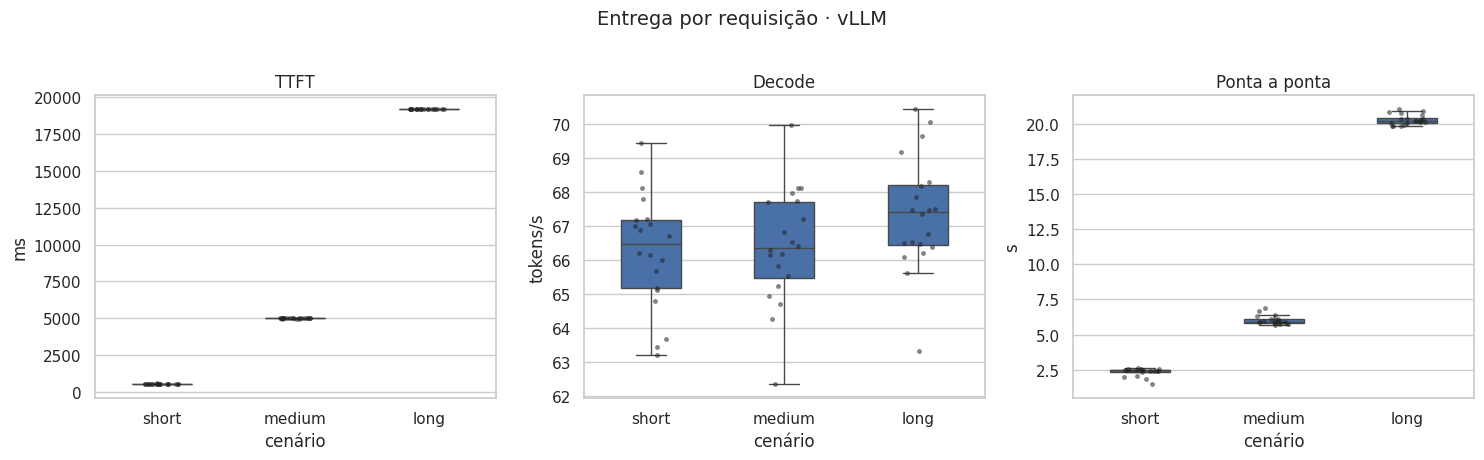

In [38]:
delivery_vllm = performance_summary(vllm) if vllm["ready"] else pd.DataFrame()
if not delivery_vllm.empty:
    display(performance_display(delivery_vllm))
    plot_delivery_distributions(vllm)

resource,scenario,observed_phase,CPU do host,Controlador de memória GPU,GPU,Pool KV,Potência GPU,RAM usada,Swap usada,VRAM usada
0,long,decode_observed,8.25 / pico 19.00 % · 20/20,100.00 / pico 100.00 % · 20/20,100.00 / pico 100.00 % · 20/20,3.82 / pico 3.86 % · 20/20,366.23 / pico 369.58 W · 20/20,26.44 / pico 30.97 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,19.28 / pico 19.28 GiB · 20/20
1,long,prefill_observed,6.92 / pico 29.10 % · 20/20,94.74 / pico 100.00 % · 20/20,94.74 / pico 100.00 % · 20/20,2.10 / pico 3.80 % · 20/20,354.43 / pico 372.34 W · 20/20,26.33 / pico 33.27 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,19.28 / pico 19.28 GiB · 20/20
2,medium,decode_observed,10.33 / pico 27.40 % · 20/20,100.00 / pico 100.00 % · 20/20,100.00 / pico 100.00 % · 20/20,1.03 / pico 1.07 % · 20/20,368.80 / pico 370.23 W · 20/20,27.71 / pico 30.58 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,19.14 / pico 19.14 GiB · 20/20
3,medium,prefill_observed,10.93 / pico 30.00 % · 20/20,94.10 / pico 100.00 % · 20/20,94.00 / pico 100.00 % · 20/20,0.00 / pico 0.00 % · 20/20,351.03 / pico 373.67 W · 20/20,27.76 / pico 31.11 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,19.14 / pico 19.14 GiB · 20/20
4,short,decode_observed,7.55 / pico 28.30 % · 20/20,76.17 / pico 100.00 % · 20/20,76.00 / pico 100.00 % · 20/20,0.16 / pico 0.18 % · 20/20,331.40 / pico 349.61 W · 20/20,26.88 / pico 27.88 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,18.84 / pico 18.84 GiB · 20/20
5,short,prefill_observed,7.40 / pico 26.30 % · 20/20,68.00 / pico 100.00 % · 20/20,68.00 / pico 100.00 % · 20/20,0.00 / pico 0.00 % · 20/20,323.17 / pico 340.51 W · 20/20,26.88 / pico 27.09 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,18.84 / pico 18.84 GiB · 20/20


**I/O e pressão de memória**

resource,scenario,observed_phase,Escrita de disco,Leitura de disco,Major page faults,Swap out
0,long,decode_observed,0.033 MiB/req · 16/20,0.000 MiB/req · 16/20,0.000 eventos/req · 16/20,0.000 MiB/req · 16/20
1,long,prefill_observed,8.888 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20
2,medium,decode_observed,0.035 MiB/req · 15/20,0.000 MiB/req · 15/20,0.000 eventos/req · 15/20,0.000 MiB/req · 15/20
3,medium,prefill_observed,3.734 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20
4,short,decode_observed,0.043 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20
5,short,prefill_observed,0.008 MiB/req · 5/20,0.000 MiB/req · 5/20,0.000 eventos/req · 5/20,0.000 MiB/req · 5/20


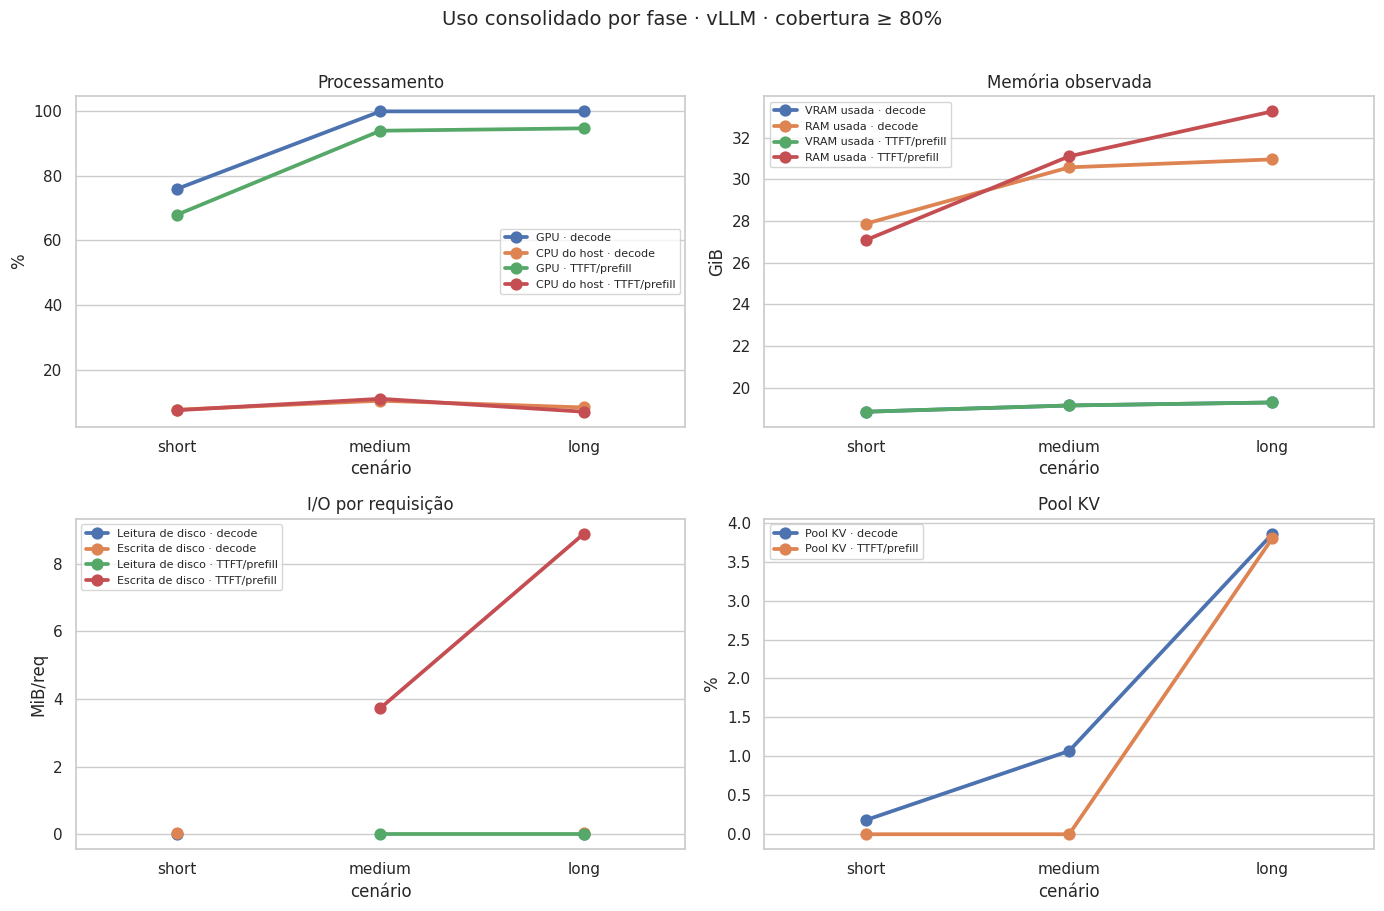

**Energia estimada pela potência da GPU**

,cenário,energia p50 (J/req),energia p95 (J/req),energia p50 (J/token),cobertura,cobertura (%)
0,short,568.679,664.776,5.096,20/20,100.0
1,medium,1942.740,2136.679,30.293,20/20,100.0
2,long,6981.878,7326.998,96.617,20/20,100.0


In [39]:
resources_vllm = resource_summary(vllm) if vllm["ready"] else pd.DataFrame()
energy_vllm = energy_summary(vllm) if vllm["ready"] else pd.DataFrame()
if not resources_vllm.empty:
    display(resource_display(resources_vllm))
    pressure_vllm = io_pressure_display(resources_vllm)
    if not pressure_vllm.empty:
        display(Markdown("**I/O e pressão de memória**"))
        display(pressure_vllm)
    plot_resource_overview(vllm, resources_vllm)
else:
    display(Markdown("Telemetria de recursos não disponível para esta run."))
if not energy_vllm.empty:
    display(Markdown("**Energia estimada pela potência da GPU**"))
    display(energy_display(energy_vllm, delivery_vllm))

,request_uid,cenário,TTFT (ms),decode (tok/s),E2E (s),critério
0,20260929T012630.907849Z-vllm-benchmark-short-m...,long,19158.74,68.17,20.04,mais próxima da mediana de TTFT do cenário esc...


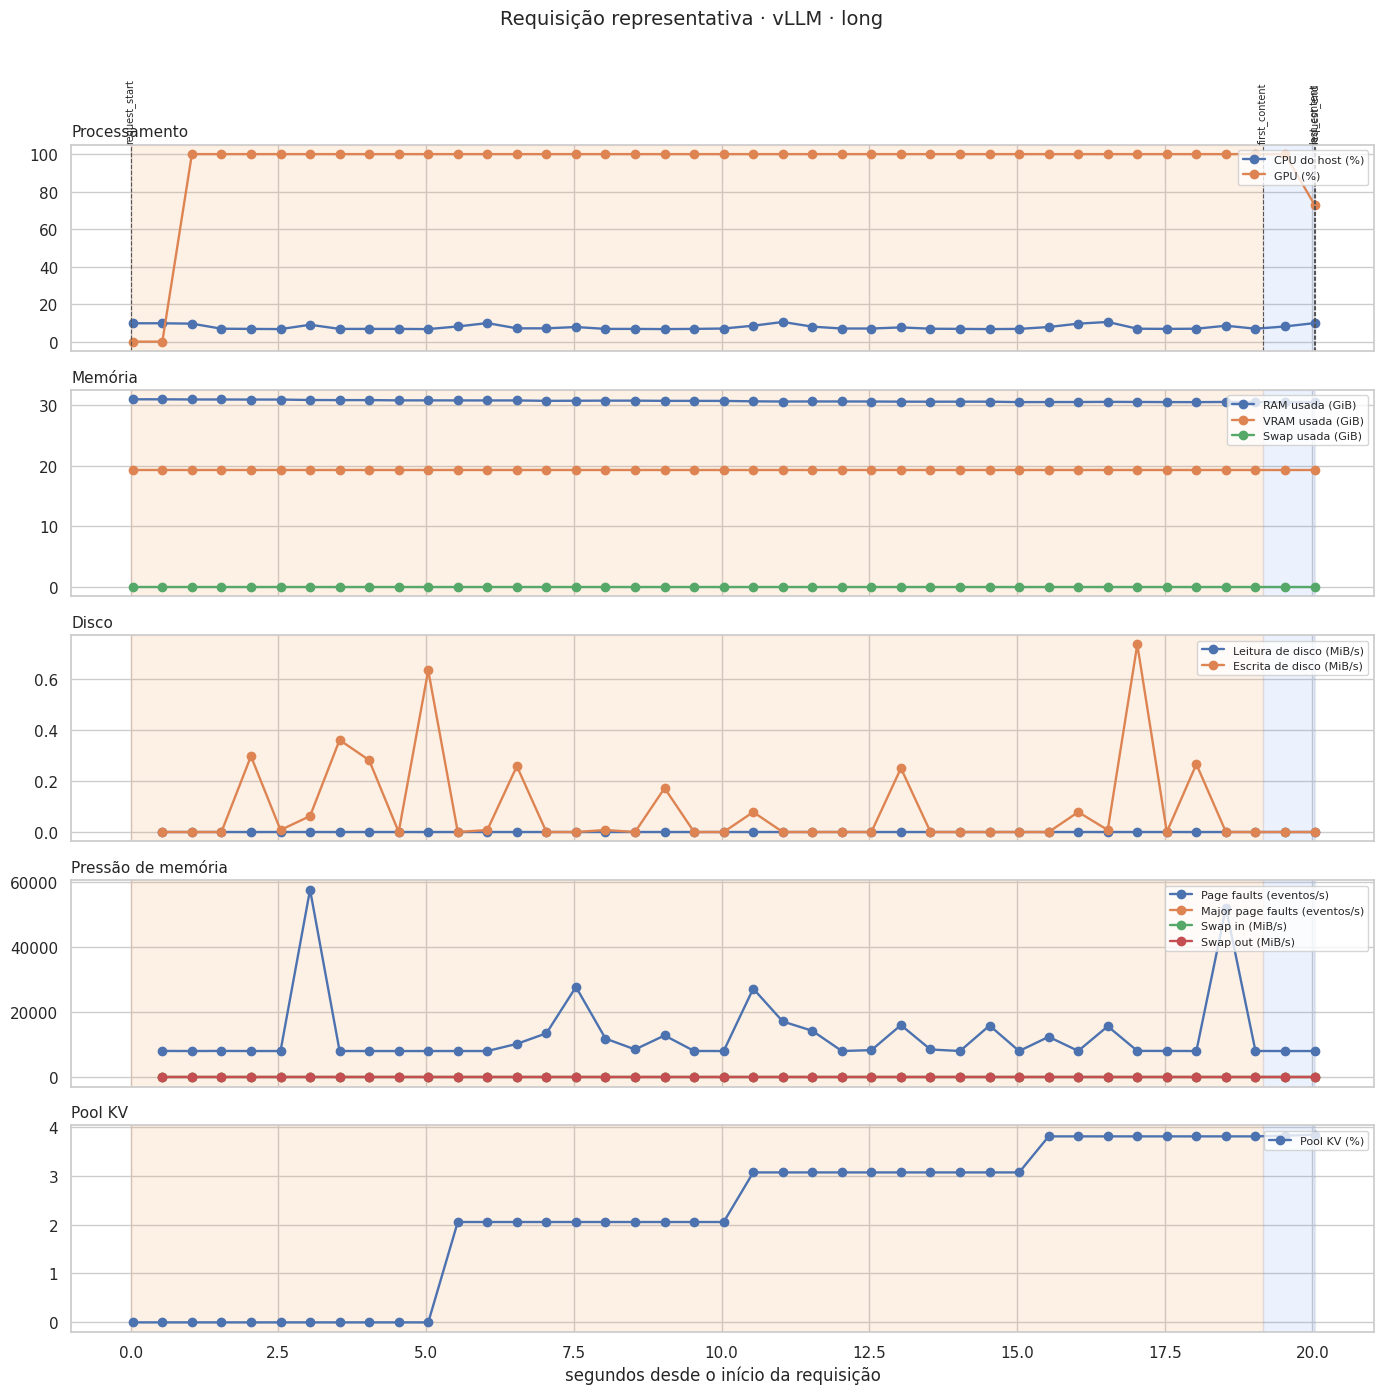

In [40]:
representative_vllm = select_representative_request(vllm) if vllm["ready"] else None
if representative_vllm is not None:
    display(pd.DataFrame([{
        "request_uid": representative_vllm["request_uid"],
        "cenário": representative_vllm["scenario"],
        "TTFT (ms)": representative_vllm["_ttft_ms"],
        "decode (tok/s)": representative_vllm["_decode_tps"],
        "E2E (s)": representative_vllm["_e2e_s"],
        "critério": "mais próxima da mediana de TTFT do cenário escolhido",
    }]).round(2))
    plot_request_timeline(vllm, representative_vllm)

### Conclusão do vLLM

In [41]:
if vllm["ready"]:
    display(Markdown(runtime_findings(vllm, delivery_vllm, resources_vllm, energy_vllm)))

**Entrega:** 60/60 requisições concluídas com sucesso.

**Escala do início da resposta:** TTFT p95 de 580.2 ms em short para 19160.7 ms em long.

**Geração:** a cauda inferior de decode ficou entre 63.4 e 65.5 tokens/s.

**Decode em long:** GPU 100.0%, CPU do host 8.2%. O contraste é compatível com pressão concentrada na GPU, sem provar sozinho a causa do gargalo.

**Memória em long:** pico observado de RAM usada 33.27 GiB, VRAM usada 19.28 GiB.

**Energia estimada em long:** mediana de 6981.9 J por requisição (20/20).

**Cobertura:** 21 combinações de métrica/cenário/fase ficaram abaixo de 80%; elas não entram nos gráficos comparativos.

**Limite:** esta instrumentação localiza sinais por fase, mas não mede PCIe nem distingue sozinha limite computacional de limite de largura de banda.

## 2. Runtime llama.cpp

O mesmo roteiro é reutilizado com `RUN_IDS["llama"]`. A conclusão é calculada apenas a partir desta run; nenhum resultado do vLLM é usado aqui.

In [42]:
llama = select_run("llama", RUN_IDS["llama"])
if llama["ready"]:
    display(run_identity(llama))
else:
    display(Markdown("**llama.cpp não disponível:** " + " ".join(llama["issues"])))

,runtime,run_id,tipo,modelo,versão,GPU,contexto,saída máxima,requisições measure,comparison_id,cache de prefixo,KV,residência
0,llama.cpp,20260929T013953.801869Z-llama.cpp-benchmark-sh...,benchmark,qwen2.5-7b-test,llama.cpp ed7ac35e1ee49cb70e4dfa9f0a2ce39b0a5e...,NVIDIA GeForce RTX 3090,8192,128,60,a5577c32bf8cc6b3,runtime-default-not-overridden,enabled-required-for-autoregressive-decode,not-observed


,cenário,total,OK,falhas,sucesso (%),entrada p50,saída p50,TTFT p50 (ms),TTFT p95 (ms),decode p50 (tok/s),decode p05 (tok/s),E2E p50 (s),E2E p95 (s)
0,short,20,20,0,100.0,256.0,128.0,82.06,88.79,90.50,89.90,1.49,1.51
1,medium,20,20,0,100.0,2048.0,62.5,460.46,466.87,90.64,89.35,1.16,1.73
2,long,20,20,0,100.0,7680.0,67.5,1768.63,1807.48,87.54,86.13,2.56,3.05


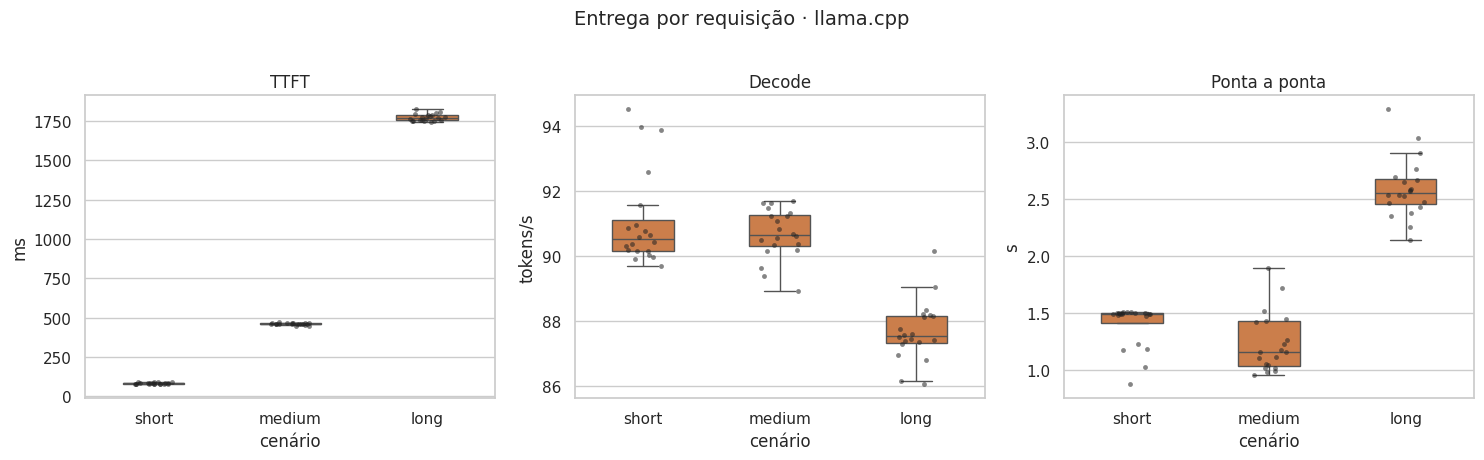

In [43]:
delivery_llama = performance_summary(llama) if llama["ready"] else pd.DataFrame()
if not delivery_llama.empty:
    display(performance_display(delivery_llama))
    plot_delivery_distributions(llama)

resource,scenario,observed_phase,CPU do host,Controlador de memória GPU,GPU,Potência GPU,RAM usada,Swap usada,VRAM usada
0,long,decode_observed,14.20 / pico 27.70 % · 19/20,50.00 / pico 95.00 % · 19/20,100.00 / pico 100.00 % · 19/20,366.75 / pico 370.42 W · 19/20,31.53 / pico 34.41 GiB · 19/20,0.00 / pico 0.00 GiB · 19/20,7.88 / pico 7.88 GiB · 19/20
1,long,prefill_observed,14.80 / pico 30.90 % · 20/20,17.00 / pico 57.00 % · 20/20,33.33 / pico 100.00 % · 20/20,184.71 / pico 296.20 W · 20/20,31.53 / pico 34.98 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,7.88 / pico 7.88 GiB · 20/20
2,medium,decode_observed,16.67 / pico 21.10 % · 20/20,54.50 / pico 94.00 % · 20/20,86.25 / pico 100.00 % · 20/20,295.98 / pico 366.65 W · 20/20,28.46 / pico 29.15 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,7.88 / pico 7.88 GiB · 20/20
3,medium,prefill_observed,16.70 / pico 29.60 % · 18/20,93.00 / pico 94.00 % · 18/20,86.50 / pico 100.00 % · 18/20,333.78 / pico 368.71 W · 18/20,28.23 / pico 29.16 GiB · 18/20,0.00 / pico 0.00 GiB · 18/20,7.88 / pico 7.88 GiB · 18/20
4,short,decode_observed,11.10 / pico 24.30 % · 20/20,93.17 / pico 97.00 % · 20/20,86.67 / pico 90.00 % · 20/20,357.22 / pico 369.44 W · 20/20,24.52 / pico 26.15 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,7.88 / pico 7.88 GiB · 20/20
5,short,prefill_observed,8.00 / pico 8.90 % · 5/20,95.00 / pico 97.00 % · 5/20,89.00 / pico 90.00 % · 5/20,355.16 / pico 360.22 W · 5/20,24.44 / pico 24.50 GiB · 5/20,0.00 / pico 0.00 GiB · 5/20,7.88 / pico 7.88 GiB · 5/20


**I/O e pressão de memória**

resource,scenario,observed_phase,Escrita de disco,Leitura de disco,Major page faults,Swap out
0,long,decode_observed,0.000 MiB/req · 12/20,0.000 MiB/req · 12/20,0.000 eventos/req · 12/20,0.000 MiB/req · 12/20
1,long,prefill_observed,0.193 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20
2,medium,decode_observed,0.000 MiB/req · 9/20,0.000 MiB/req · 9/20,0.000 eventos/req · 9/20,0.000 MiB/req · 9/20
3,short,decode_observed,0.000 MiB/req · 19/20,0.000 MiB/req · 19/20,0.000 eventos/req · 19/20,0.000 MiB/req · 19/20


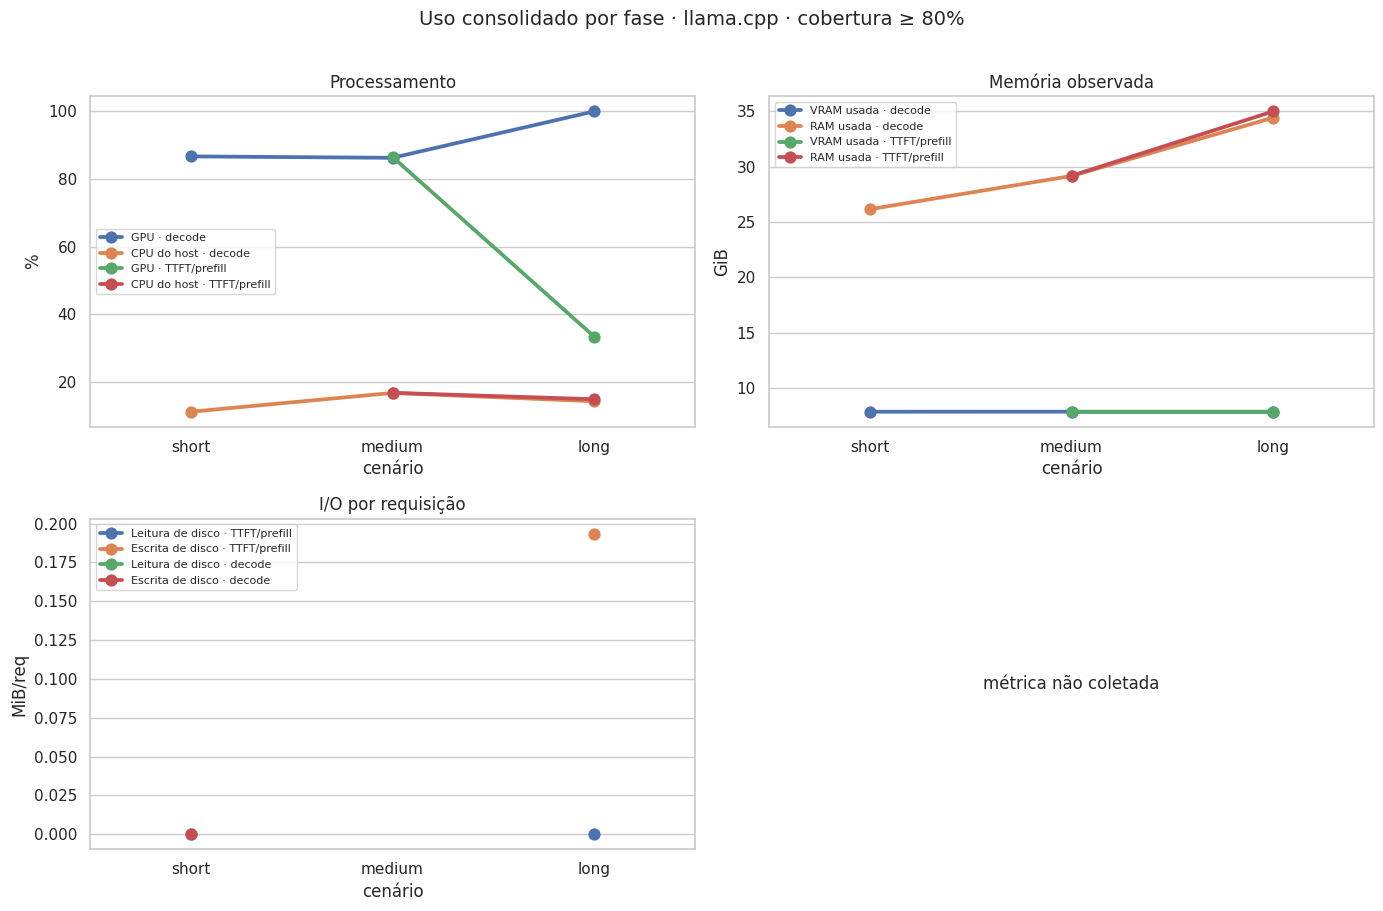

**Energia estimada pela potência da GPU**

,cenário,energia p50 (J/req),energia p95 (J/req),energia p50 (J/token),cobertura,cobertura (%)
0,short,354.080,359.452,2.768,19/20,95.0
1,medium,164.682,459.469,3.300,20/20,100.0
2,long,477.461,627.431,7.124,20/20,100.0


In [44]:
resources_llama = resource_summary(llama) if llama["ready"] else pd.DataFrame()
energy_llama = energy_summary(llama) if llama["ready"] else pd.DataFrame()
if not resources_llama.empty:
    display(resource_display(resources_llama))
    pressure_llama = io_pressure_display(resources_llama)
    if not pressure_llama.empty:
        display(Markdown("**I/O e pressão de memória**"))
        display(pressure_llama)
    plot_resource_overview(llama, resources_llama)
if not energy_llama.empty:
    display(Markdown("**Energia estimada pela potência da GPU**"))
    display(energy_display(energy_llama, delivery_llama))

,request_uid,cenário,TTFT (ms),decode (tok/s),E2E (s),critério
0,20260929T013953.801869Z-llama.cpp-benchmark-sh...,long,1770.42,87.39,2.65,mais próxima da mediana de TTFT do cenário esc...


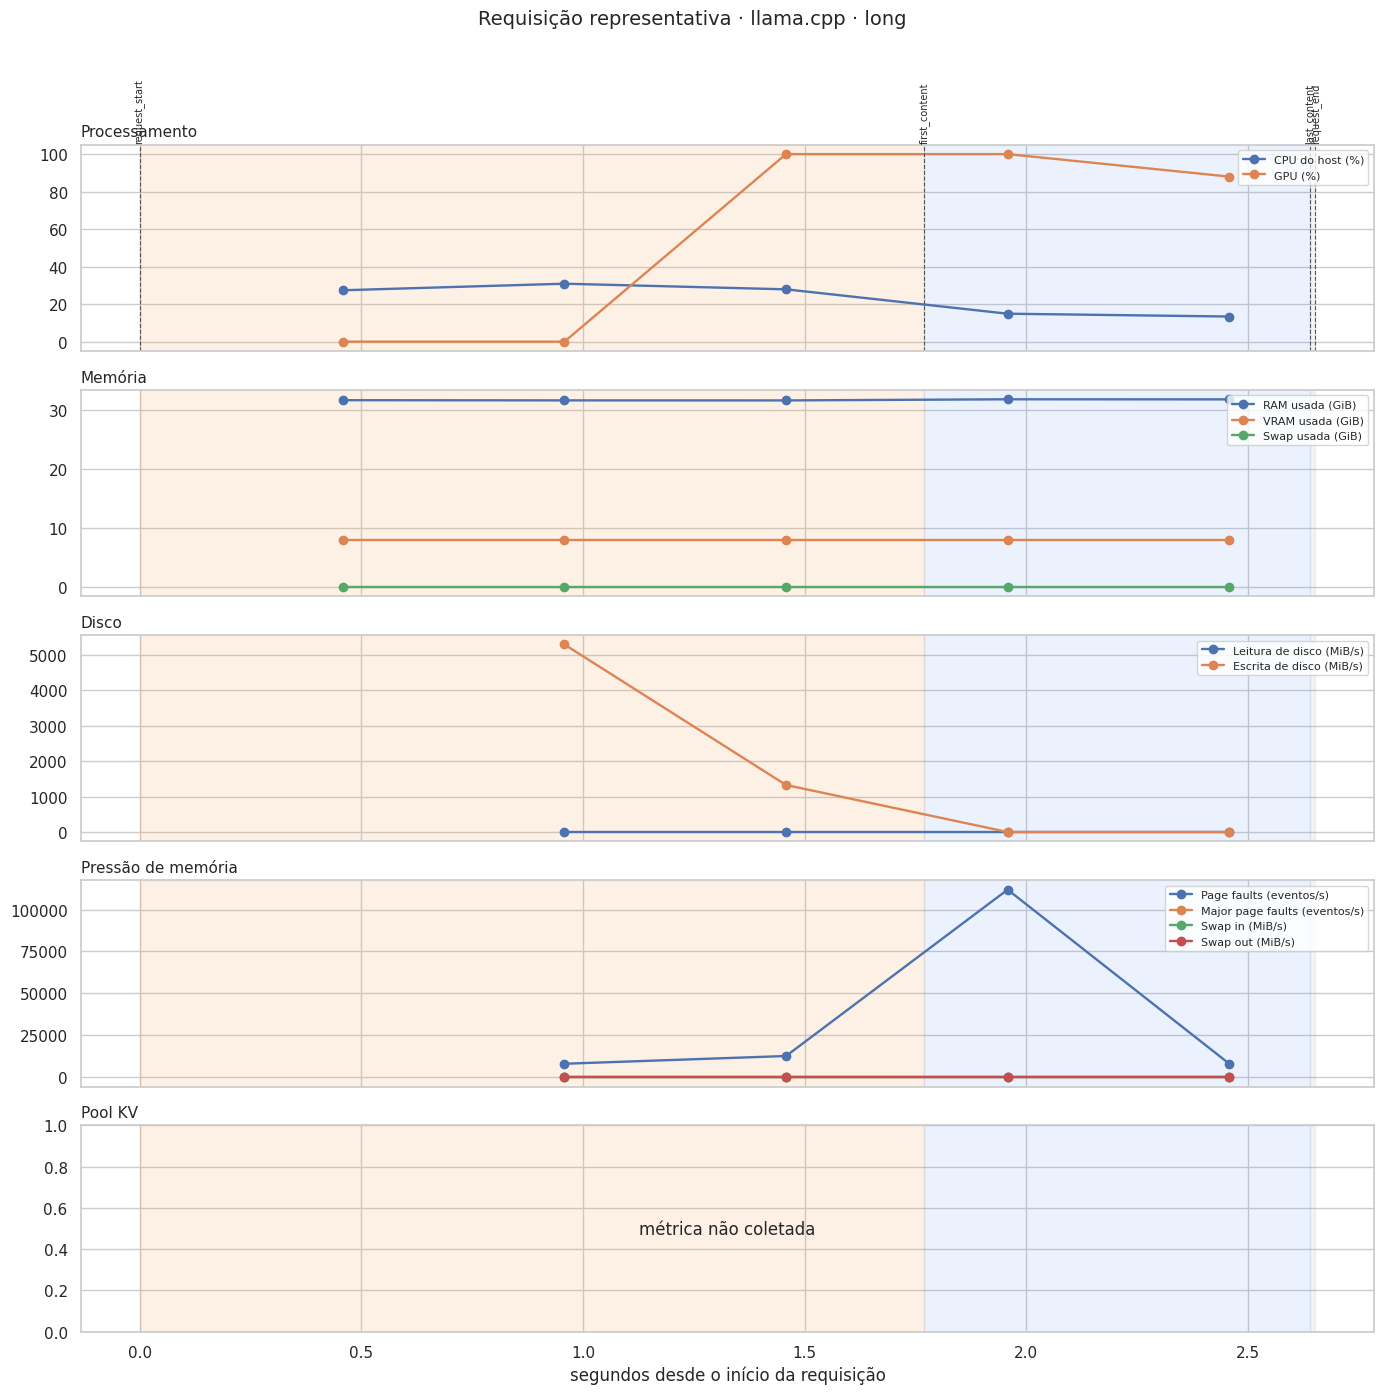

In [45]:
representative_llama = select_representative_request(llama) if llama["ready"] else None
if representative_llama is not None:
    display(pd.DataFrame([{
        "request_uid": representative_llama["request_uid"],
        "cenário": representative_llama["scenario"],
        "TTFT (ms)": representative_llama["_ttft_ms"],
        "decode (tok/s)": representative_llama["_decode_tps"],
        "E2E (s)": representative_llama["_e2e_s"],
        "critério": "mais próxima da mediana de TTFT do cenário escolhido",
    }]).round(2))
    plot_request_timeline(llama, representative_llama)

### Conclusão do llama.cpp

In [46]:
if llama["ready"]:
    display(Markdown(runtime_findings(llama, delivery_llama, resources_llama, energy_llama)))

**Entrega:** 60/60 requisições concluídas com sucesso.

**Escala do início da resposta:** TTFT p95 de 88.8 ms em short para 1807.5 ms em long.

**Geração:** a cauda inferior de decode ficou entre 86.1 e 89.9 tokens/s.

**Decode em long:** GPU 100.0%, CPU do host 14.2%. O contraste é compatível com pressão concentrada na GPU, sem provar sozinho a causa do gargalo.

**Memória em long:** pico observado de RAM usada 34.98 GiB, VRAM usada 7.88 GiB.

**Energia estimada em long:** mediana de 477.5 J por requisição (20/20).

**Cobertura:** 36 combinações de métrica/cenário/fase ficaram abaixo de 80%; elas não entram nos gráficos comparativos.

**Limite:** esta instrumentação localiza sinais por fase, mas não mede PCIe nem distingue sozinha limite computacional de limite de largura de banda.

## 3. Runtime Ollama

O terceiro bloco usa `RUN_IDS["ollama"]` e preserva as mesmas tabelas, unidades e critérios das análises anteriores.

In [47]:
ollama = select_run("ollama", RUN_IDS["ollama"])
if ollama["ready"]:
    display(run_identity(ollama))
else:
    display(Markdown("**Ollama não disponível:** " + " ".join(ollama["issues"])))

,runtime,run_id,tipo,modelo,versão,GPU,contexto,saída máxima,requisições measure,comparison_id,cache de prefixo,KV,residência
0,Ollama,20260929T014325.656279Z-ollama-benchmark-short...,benchmark,qwen2.5-7b-test,Ollama 0.34.0,NVIDIA GeForce RTX 3090,8192,128,60,a5577c32bf8cc6b3,not-exposed-by-runtime-interface,enabled-required-for-autoregressive-decode,policy-configured-not-observed


,cenário,total,OK,falhas,sucesso (%),entrada p50,saída p50,TTFT p50 (ms),TTFT p95 (ms),decode p50 (tok/s),decode p05 (tok/s),E2E p50 (s),E2E p95 (s)
0,short,20,20,0,100.0,256.0,128.0,154.73,291.11,60.26,57.92,2.28,2.41
1,medium,20,20,0,100.0,2048.0,67.0,455.18,474.31,62.57,61.03,1.52,2.26
2,long,20,20,0,100.0,7680.0,68.5,1786.54,1836.05,61.33,59.98,2.90,3.64


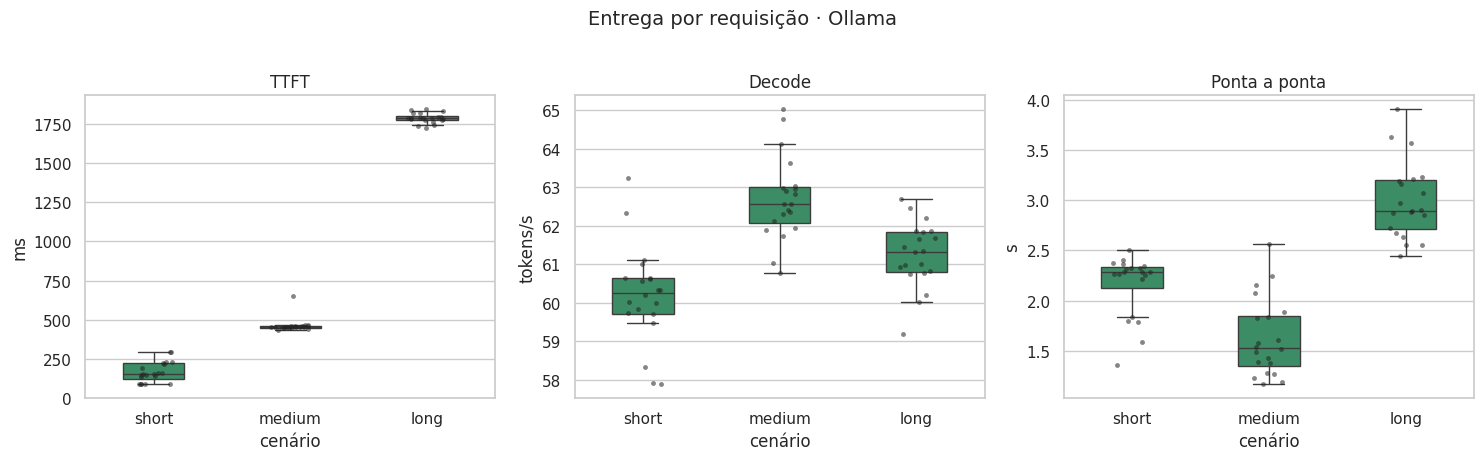

In [48]:
delivery_ollama = performance_summary(ollama) if ollama["ready"] else pd.DataFrame()
if not delivery_ollama.empty:
    display(performance_display(delivery_ollama))
    plot_delivery_distributions(ollama)

resource,scenario,observed_phase,CPU do host,Controlador de memória GPU,GPU,Potência GPU,RAM usada,Swap usada,VRAM usada
0,long,decode_observed,18.65 / pico 32.80 % · 20/20,30.00 / pico 77.00 % · 20/20,91.50 / pico 100.00 % · 20/20,309.56 / pico 362.73 W · 20/20,31.05 / pico 35.51 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,8.03 / pico 8.03 GiB · 20/20
1,long,prefill_observed,13.70 / pico 35.10 % · 20/20,6.42 / pico 35.00 % · 20/20,25.67 / pico 100.00 % · 20/20,151.51 / pico 246.34 W · 20/20,30.97 / pico 35.74 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,8.03 / pico 8.03 GiB · 20/20
2,medium,decode_observed,28.88 / pico 39.70 % · 20/20,45.25 / pico 67.00 % · 20/20,59.00 / pico 100.00 % · 20/20,243.66 / pico 323.51 W · 20/20,26.46 / pico 30.78 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,8.03 / pico 8.28 GiB · 20/20
3,medium,prefill_observed,32.60 / pico 44.50 % · 17/20,61.00 / pico 67.00 % · 17/20,57.00 / pico 100.00 % · 17/20,304.77 / pico 328.18 W · 17/20,26.25 / pico 29.54 GiB · 17/20,0.00 / pico 0.00 GiB · 17/20,8.03 / pico 8.03 GiB · 17/20
4,short,decode_observed,34.00 / pico 50.60 % · 20/20,64.12 / pico 65.00 % · 20/20,60.00 / pico 62.00 % · 20/20,290.68 / pico 304.96 W · 20/20,24.70 / pico 25.13 GiB · 20/20,0.00 / pico 0.00 GiB · 20/20,8.02 / pico 8.02 GiB · 20/20
5,short,prefill_observed,32.30 / pico 36.60 % · 5/20,65.00 / pico 65.00 % · 5/20,60.00 / pico 60.00 % · 5/20,303.03 / pico 305.17 W · 5/20,24.83 / pico 24.86 GiB · 5/20,0.00 / pico 0.00 GiB · 5/20,8.02 / pico 8.02 GiB · 5/20


**I/O e pressão de memória**

resource,scenario,observed_phase,Escrita de disco,Leitura de disco,Major page faults,Swap out
0,long,decode_observed,0.004 MiB/req · 19/20,0.000 MiB/req · 19/20,0.000 eventos/req · 19/20,0.000 MiB/req · 19/20
1,long,prefill_observed,0.008 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20
2,medium,decode_observed,0.016 MiB/req · 17/20,0.000 MiB/req · 17/20,0.000 eventos/req · 17/20,0.000 MiB/req · 17/20
3,short,decode_observed,0.062 MiB/req · 20/20,0.000 MiB/req · 20/20,0.000 eventos/req · 20/20,0.000 MiB/req · 20/20


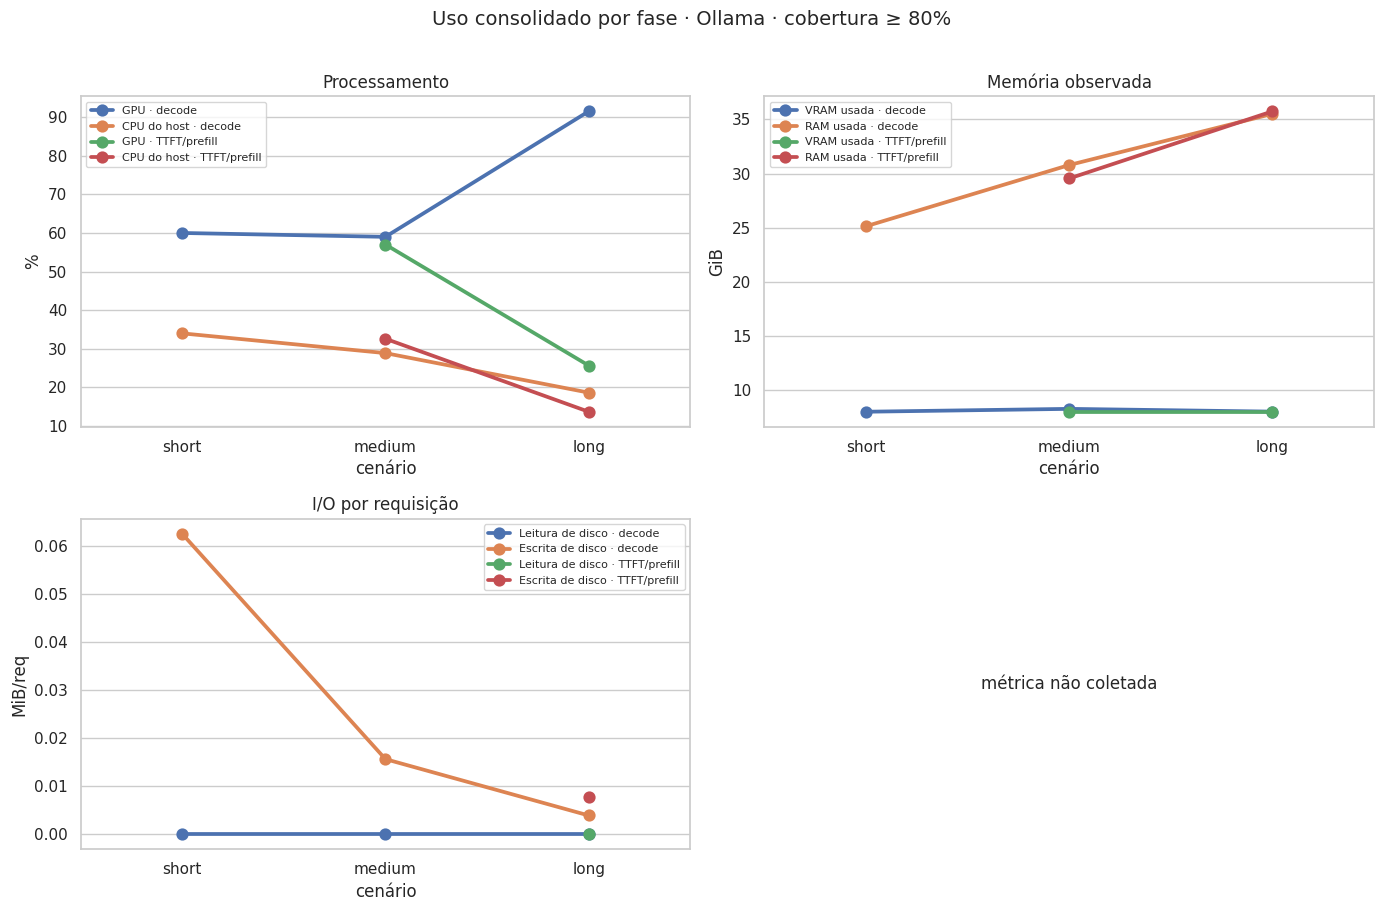

**Energia estimada pela potência da GPU**

,cenário,energia p50 (J/req),energia p95 (J/req),energia p50 (J/token),cobertura,cobertura (%)
0,short,497.289,582.980,4.305,20/20,100.0
1,medium,262.955,427.224,3.967,20/20,100.0
2,long,511.852,759.145,6.910,20/20,100.0


In [49]:
resources_ollama = resource_summary(ollama) if ollama["ready"] else pd.DataFrame()
energy_ollama = energy_summary(ollama) if ollama["ready"] else pd.DataFrame()
if not resources_ollama.empty:
    display(resource_display(resources_ollama))
    pressure_ollama = io_pressure_display(resources_ollama)
    if not pressure_ollama.empty:
        display(Markdown("**I/O e pressão de memória**"))
        display(pressure_ollama)
    plot_resource_overview(ollama, resources_ollama)
if not energy_ollama.empty:
    display(Markdown("**Energia estimada pela potência da GPU**"))
    display(energy_display(energy_ollama, delivery_ollama))

,request_uid,cenário,TTFT (ms),decode (tok/s),E2E (s),critério
0,20260929T014325.656279Z-ollama-benchmark-short...,long,1787.77,60.79,2.9,mais próxima da mediana de TTFT do cenário esc...


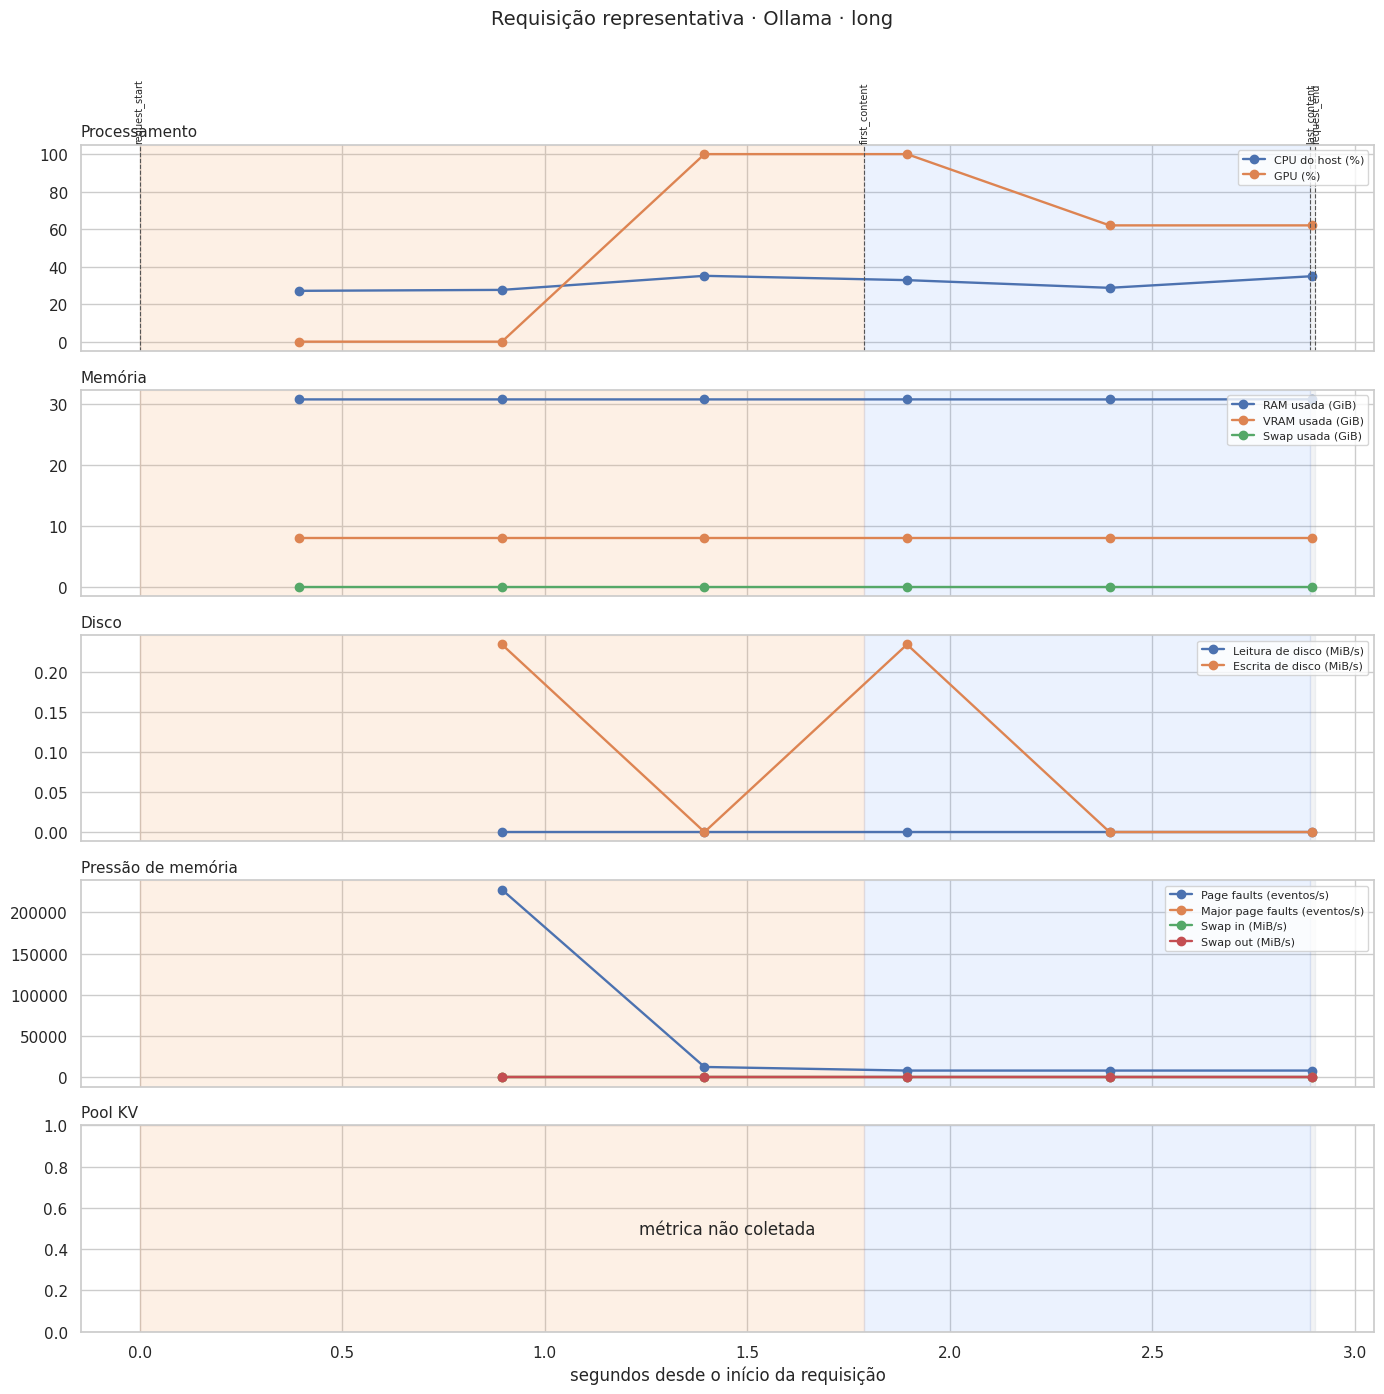

In [50]:
representative_ollama = select_representative_request(ollama) if ollama["ready"] else None
if representative_ollama is not None:
    display(pd.DataFrame([{
        "request_uid": representative_ollama["request_uid"],
        "cenário": representative_ollama["scenario"],
        "TTFT (ms)": representative_ollama["_ttft_ms"],
        "decode (tok/s)": representative_ollama["_decode_tps"],
        "E2E (s)": representative_ollama["_e2e_s"],
        "critério": "mais próxima da mediana de TTFT do cenário escolhido",
    }]).round(2))
    plot_request_timeline(ollama, representative_ollama)

### Conclusão do Ollama

In [51]:
if ollama["ready"]:
    display(Markdown(runtime_findings(ollama, delivery_ollama, resources_ollama, energy_ollama)))

**Entrega:** 60/60 requisições concluídas com sucesso.

**Escala do início da resposta:** TTFT p95 de 291.1 ms em short para 1836.0 ms em long.

**Geração:** a cauda inferior de decode ficou entre 57.9 e 61.0 tokens/s.

**Decode em long:** GPU 91.5%, CPU do host 18.6%. O contraste é compatível com pressão concentrada na GPU, sem provar sozinho a causa do gargalo.

**Memória em long:** pico observado de RAM usada 35.74 GiB, VRAM usada 8.03 GiB.

**Energia estimada em long:** mediana de 511.9 J por requisição (20/20).

**Cobertura:** 16 combinações de métrica/cenário/fase ficaram abaixo de 80%; elas não entram nos gráficos comparativos.

**Limite:** esta instrumentação localiza sinais por fase, mas não mede PCIe nem distingue sozinha limite computacional de limite de largura de banda.

## 4. Consolidação comparativa

As análises individuais continuam válidas mesmo quando o gate falha. Tabelas-heatmap e gráficos de comparação só aparecem quando as três runs estão íntegras, representam os runtimes esperados, compartilham `comparison_id` e possuem requisições pareadas.

In [52]:
runtime_results = {"vllm": vllm, "llama": llama, "ollama": ollama}
comparison_gate = build_comparability(runtime_results)
display(comparison_gate["table"])
if comparison_gate["comparable"]:
    display(Markdown("**Gate aprovado:** as três runs podem alimentar a comparação formal."))
else:
    display(Markdown("**Comparação ainda não liberada.** " + " ".join(comparison_gate["reasons"])))

,runtime esperado,run_id,runtime observado,status,comparison_id,identidade completa,modelo SHA,tokenizer SHA,contexto,saída
0,vLLM,20260929T012630.907849Z-vllm-benchmark-short-m...,vllm,pronta,a5577c32bf8cc6b3,True,7c1008279b86,08ea1d3ec42a,8192,128
1,llama.cpp,20260929T013953.801869Z-llama.cpp-benchmark-sh...,llama.cpp,pronta,a5577c32bf8cc6b3,True,7c1008279b86,08ea1d3ec42a,8192,128
2,Ollama,20260929T014325.656279Z-ollama-benchmark-short...,ollama,pronta,a5577c32bf8cc6b3,True,7c1008279b86,08ea1d3ec42a,8192,128


**Gate aprovado:** as três runs podem alimentar a comparação formal.

In [53]:
delivery_frames = [frame for frame in [delivery_vllm, delivery_llama, delivery_ollama] if not frame.empty]
resource_frames = [frame for frame in [resources_vllm, resources_llama, resources_ollama] if not frame.empty]
energy_frames = [frame for frame in [energy_vllm, energy_llama, energy_ollama] if not frame.empty]

delivery_all = pd.concat(delivery_frames, ignore_index=True) if delivery_frames else pd.DataFrame()
resources_all = pd.concat(resource_frames, ignore_index=True) if resource_frames else pd.DataFrame()
energy_all = pd.concat(energy_frames, ignore_index=True) if energy_frames else pd.DataFrame()

if comparison_gate["comparable"] and not delivery_all.empty:
    display(performance_display(delivery_all.assign(scenario=delivery_all["runtime"] + " · " + delivery_all["scenario"])))

,cenário,total,OK,falhas,sucesso (%),entrada p50,saída p50,TTFT p50 (ms),TTFT p95 (ms),decode p50 (tok/s),decode p05 (tok/s),E2E p50 (s),E2E p95 (s)
0,vLLM · short,20,20,0,100.0,256.0,128.0,542.23,580.18,66.45,63.43,2.45,2.57
1,vLLM · medium,20,20,0,100.0,2048.0,59.0,4998.65,5038.20,66.35,64.15,5.92,6.70
2,vLLM · long,20,20,0,100.0,7680.0,72.5,19158.84,19160.66,67.39,65.51,20.22,20.89
3,llama.cpp · short,20,20,0,100.0,256.0,128.0,82.06,88.79,90.50,89.90,1.49,1.51
4,llama.cpp · medium,20,20,0,100.0,2048.0,62.5,460.46,466.87,90.64,89.35,1.16,1.73
5,llama.cpp · long,20,20,0,100.0,7680.0,67.5,1768.63,1807.48,87.54,86.13,2.56,3.05
6,Ollama · short,20,20,0,100.0,256.0,128.0,154.73,291.11,60.26,57.92,2.28,2.41
7,Ollama · medium,20,20,0,100.0,2048.0,67.0,455.18,474.31,62.57,61.03,1.52,2.26
8,Ollama · long,20,20,0,100.0,7680.0,68.5,1786.54,1836.05,61.33,59.98,2.90,3.64


### Heatmaps executivos

O primeiro heatmap usa direção de qualidade apenas para resultado entregue. O segundo usa intensidade azul neutra: mais escuro significa maior uso, não melhor runtime. Cada célula contém valor e cobertura.

In [54]:
if comparison_gate["comparable"]:
    display(result_heatmap(delivery_all))
    display(resource_heatmap(resources_all, delivery_all))
else:
    display(Markdown("Heatmaps comparativos omitidos até a aprovação do gate."))

,vLLM,llama.cpp,Ollama
short · Sucesso (%),100.00 · 100%,100.00 · 100%,100.00 · 100%
short · TTFT p95 (ms),580.18 · 100%,88.79 · 100%,291.11 · 100%
short · Decode p05 (tok/s),63.43 · 100%,89.90 · 100%,57.92 · 100%
short · E2E p95 (s),2.57 · 100%,1.51 · 100%,2.41 · 100%
medium · Sucesso (%),100.00 · 100%,100.00 · 100%,100.00 · 100%
medium · TTFT p95 (ms),5038.20 · 100%,466.87 · 100%,474.31 · 100%
medium · Decode p05 (tok/s),64.15 · 100%,89.35 · 100%,61.03 · 100%
medium · E2E p95 (s),6.70 · 100%,1.73 · 100%,2.26 · 100%
long · Sucesso (%),100.00 · 100%,100.00 · 100%,100.00 · 100%
long · TTFT p95 (ms),19160.66 · 100%,1807.48 · 100%,1836.05 · 100%


,vLLM,llama.cpp,Ollama
GPU decode (%),100.00 · 100%,100.00 · 95%,91.50 · 100%
Controlador GPU decode (%),100.00 · 100%,50.00 · 95%,30.00 · 100%
VRAM pico (GiB),19.28 · 100%,7.88 · 100%,8.03 · 100%
CPU decode (%),8.25 · 100%,14.20 · 95%,18.65 · 100%
RAM pico (GiB),33.27 · 100%,34.98 · 100%,35.74 · 100%
Potência GPU decode (W),366.23 · 100%,366.75 · 95%,309.56 · 100%
Swap out (MiB/req),0.00 · 100%,0.00 · 100%,0.00 · 100%
Major faults (eventos/req),0.00 · 100%,0.00 · 100%,0.00 · 100%


### Gráficos comparativos enxutos

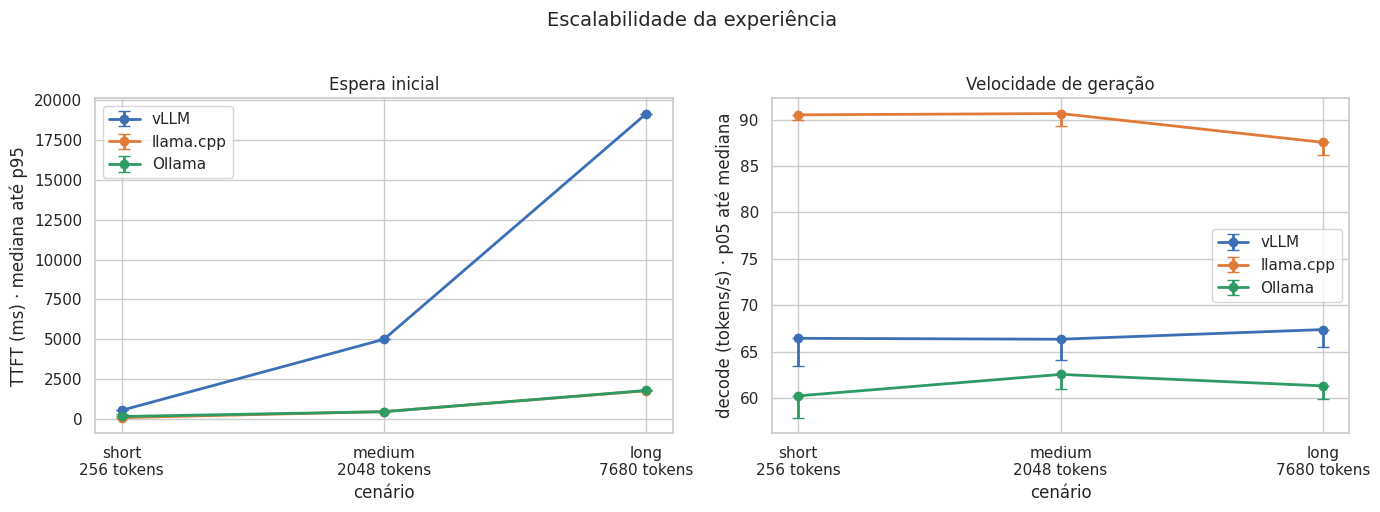

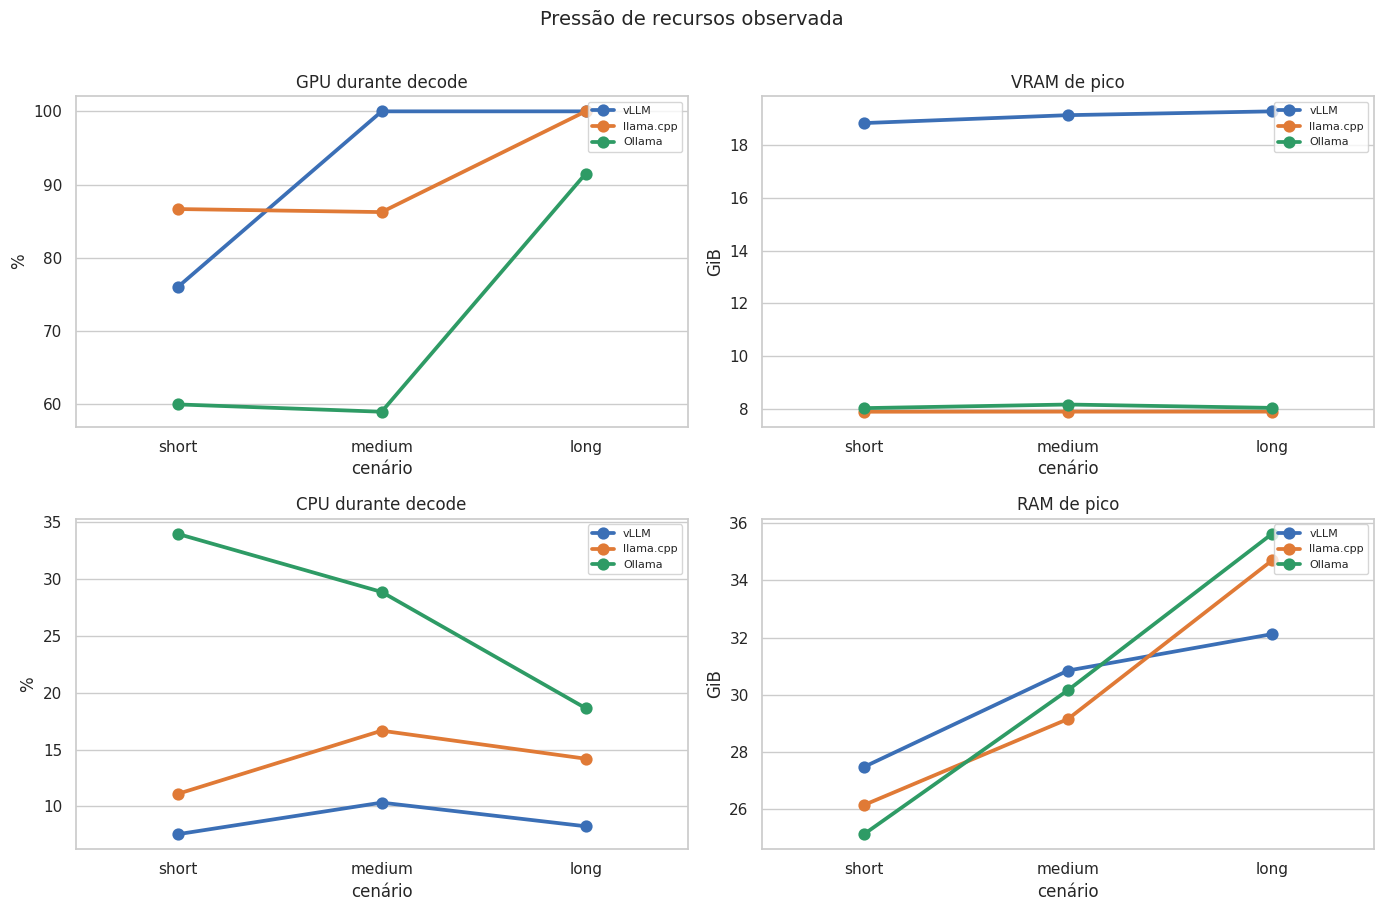

/tmp/ipykernel_1218238/2240733794.py:103: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#222222'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1218238/2240733794.py:103: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#222222'` for the same effect.

  sns.stripplot(


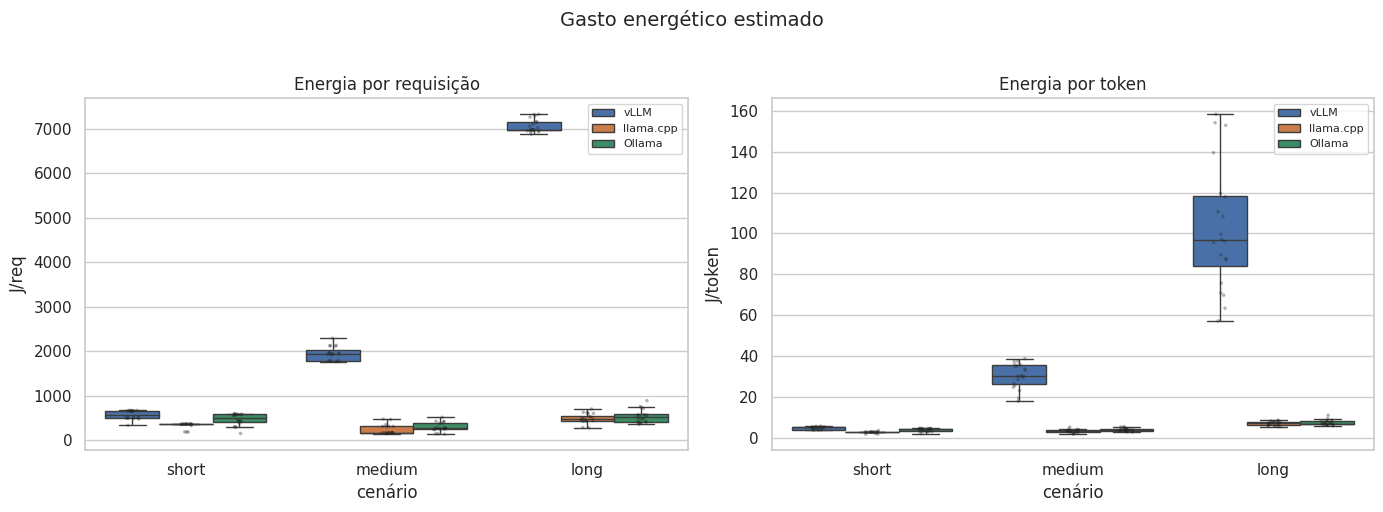

In [55]:
if comparison_gate["comparable"]:
    plot_comparison_performance(delivery_all)
    plot_comparison_resources(resources_all)
    energy_plotted = plot_energy_comparison(energy_all, delivery_all)
    if not energy_plotted:
        display(Markdown("Energia não exibida: a potência não possui cobertura suficiente para integração comparável."))
else:
    display(Markdown("Gráficos comparativos omitidos; as três análises individuais permanecem disponíveis acima."))

### Conclusão comparativa

A tabela de metas usa o pior cenário de cada runtime. A síntese seguinte relata apenas valores observados com cobertura suficiente; não transforma diferenças descritivas em significância estatística.

In [56]:
if comparison_gate["comparable"]:
    display(slo_summary(delivery_all))
    display(Markdown(comparison_findings(delivery_all, resources_all, energy_all)))
else:
    display(Markdown(
        "A conclusão comparativa permanece bloqueada. Complete as três runs e resolva os itens do gate; "
        "as conclusões individuais acima continuam válidas."
    ))

,runtime,pior sucesso (%),meta sucesso,maior TTFT p95 (ms),meta TTFT,menor decode p05 (tok/s),meta decode,resultado das metas definidas
0,vLLM,100.0,atende,19160.66,não definida,63.43,não definida,atende
1,llama.cpp,100.0,atende,1807.48,não definida,86.13,não definida,atende
2,Ollama,100.0,atende,1836.05,não definida,57.92,não definida,atende


**Metas configuradas:** vLLM, llama.cpp, Ollama atenderam a todas as metas atualmente definidas.

**short:** menor/maior valor observado — TTFT p95: llama.cpp 88.79 ms; decode p05: llama.cpp 89.90 tok/s; E2E p95: llama.cpp 1.51 s, saída p50 128 tokens.

**medium:** menor/maior valor observado — TTFT p95: llama.cpp 466.87 ms; decode p05: llama.cpp 89.35 tok/s; E2E p95: llama.cpp 1.73 s, saída p50 62 tokens.

**long:** menor/maior valor observado — TTFT p95: llama.cpp 1807.48 ms; decode p05: llama.cpp 86.13 tok/s; E2E p95: llama.cpp 3.05 s, saída p50 68 tokens.

**Pressão de memória em long:** menor valor observado — VRAM de pico: llama.cpp 7.88 GiB; RAM de pico: vLLM 33.27 GiB.

**Energia em long:** menor mediana estimada em llama.cpp, 477.5 J por requisição.

**Decisão:** não há score composto nem teste de significância; escolha pelo eixo que representa o caso de uso e trate diferenças pequenas como estimativas a confirmar em novas rodadas.